# CSF Proteomics AD Subtyping with SuStaIn
## Emory CSF Dataset — 33 WGCNA Module Eigengenes, N = 296

This notebook implements the full **SuStaIn (Subtype and Stage Inference)** analysis used in:

> *Afshar et al. — Subtype and Stage Inference Identifies Five Alzheimer’s Disease Subtypes Based on the CSF Proteome*

### Analysis overview
1. Load and preprocess 33 CSF WGCNA module eigengenes (Emory cohort, N = 296)
2. Z-score relative to the control population
3. Fit SuStaIn models for 1–6 subtypes
4. Select the optimal number of subtypes via cross-validation
5. Assign subjects to subtypes and stages
6. Characterise subtypes by CSF traits
7. Visualise subtype classification probabilities
8. Compare with k-means, hierarchical clustering, and NMF
9. Validate in ADNI (N = 595) (Will be added here by Oct 15)

### Data file required
```
FNIH296CSF-cleanDat.MEs.ModuleAssignments.Traits_forTraining_withShiva(EBD).xlsb
```
This file contains 33 module eigenprotein and traits.


---
## 1 · Environment Setup

All packages used in this analysis are imported here. `pySuStaIn` is the core library; all others are standard scientific Python.


In [41]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import sklearn.model_selection
import pandas as pd
import pylab
import sys
import pySuStaIn
sys.path.insert(0,'/Users/shivaafshar/anaconda3/lib/python3.11/site-packages//sim/')
from simfuncs import generate_random_Zscore_sustain_model, generate_data_Zscore_sustain
import seaborn as sns
from scipy import stats



---
## 2 · Data Loading

The Emory CSF dataset is stored as a multi-sheet `.xlsb` workbook.  
We use two sheets:

| Sheet | Contents |
|---|---|
| `MEs(34modules)` | 296 samples × 34 WGCNA module eigengenes |
| `SUSTAIN.numericMeta-Stage+Subty` | Sample-level metadata (Group, APOE, SuStaIn assignments, etc.) |

The `turquoise` module is excluded because it is an ambiguous biologically coherent module.


In [44]:
############################### Loading data 

data = pd.read_excel(
    "FNIH296CSF-cleanDat.MEs.ModuleAssignments.Traits_forTraining_withShiva(EBD).xlsb", 
    sheet_name="MEs(34modules)", 
    engine='pyxlsb'
)
data.index = data.iloc[:, 0]
data = data.iloc[:, 1:].T
data=data.drop(columns=['turquoise'])

numeric_meta=pd.read_excel("FNIH296CSF-cleanDat.MEs.ModuleAssignments.Traits_forTraining_withShiva(EBD).xlsb",sheet_name="SUSTAIN.numericMeta-Stage+Subty",engine='pyxlsb')
numeric_meta.index=numeric_meta.iloc[:,0]
numeric_meta=numeric_meta.iloc[:,1:]

data_normalized = (data - data.mean()) / data.std()
#print(pd.DataFrame(data.mean()))

data_control = data_normalized.loc[
    (numeric_meta["Group"] == "Control") & 
    (numeric_meta["WGCNA-unstandardized-net"].isin(["brown", "red"]))].astype(float)

module_name=data_normalized.columns
samples=data_normalized.index
np.array(module_name)

color_to_ontologies=pd.read_csv("module_colors.csv")
mapping_dict = dict(zip(color_to_ontologies['Module color'], color_to_ontologies['num-col-ontology']))
#color_to_ontologies=pd.read_csv("Standardized Network Ontologies.csv")
#mapping_dict = dict(zip(color_to_ontologies['Color'], color_to_ontologies['num-col-ontology']))

data= data.rename(columns=mapping_dict)
data_normalized= data_normalized.rename(columns=mapping_dict)
data_control= data_control.rename(columns=mapping_dict)

module_name=data_normalized.columns

np.array(module_name)



array(['M33|darkolivegreen|Oxidant detoxification/MAPK signalling',
       'M26|darkorange|Neddylation', 'M32|violet|L1CAM/ Axon development',
       'M22|darkgreen|Golgi/Glycosylation ',
       'M28|skyblue|Neurons system development',
       'M17|grey60|synpatic vesicle/SNAP-SNARE comlex',
       'M4|yellow|Autophagy/Ubiquitination', 'M19|lightyellow|Ambiguous',
       'M3|brown|Neuron development', 'M9|magenta|Ambiguous',
       'M8|pink|Semaphorin signaling',
       'M15|midnightblue|Neurexin/Synpatic membrance',
       'M24|darkgrey|Axolemma/Semaphorin complex',
       'M11|greenyellow|Axonogenesis', 'M23|darkturquoise|Ambiguous',
       'M34|darkmagenta|Mitochondrion',
       'M5|green|Wnt-Fizzled signaling/Protein transport',
       'M7|black|Lysosome', 'M6|red|Ambiguous',
       'M2|blue|Complement/Coagulation', 'M13|salmon|Immunoglobulins',
       'M16|lightcyan|Ambiguous', 'M14|cyan|Translation',
       'M27|white|Nucleosome', 'M10|purple|Golgi/Glycosylation',
       'M20|roy

---
## 3 · Data Preprocessing — Control-Based Z-Scoring

SuStaIn requires each feature to be expressed as a **z-score relative to the control population**, where higher z-scores indicate greater abnormality.

Steps:
1. Identify control subjects (amyloid-negative, and not in outlier WGCNA subclusters `red` or `brown`).
2. Compute control mean and SD for each module.
3. Z-score all subjects against those control statistics.
4. **Sign-flip** modules whose mean in the full cohort is *lower* than the control mean — SuStaIn models biomarkers that increase with disease, so decreasing biomarkers are multiplied by −1 to convert them to an increasing scale.


In [45]:
data=data_normalized#
# compute the mean and standard deviation of the control population
mean_control = np.mean(data_control,axis=0)
std_control = np.std(data_control,axis=0)

# z-score the data
data = (data-mean_control)/std_control
#data_96=(data_96-mean_control)/std_control
data_control = (data_control-mean_control)/std_control

# multiply data for decreasing biomarkers by -1
mean_data = np.mean(data,axis=0)
data.iloc[:,np.where(mean_data<np.mean(data_control,axis=0))[0]]=-1*data.iloc[:,np.where(mean_data<np.mean(data_control,axis=0))[0]]
data_control.iloc[:,np.where(mean_data<np.mean(data_control,axis=0))[0]]=-1*data_control.iloc[:,np.where(mean_data<np.mean(data_control,axis=0))[0]]

#mean_data_96 = np.mean(data_96,axis=0)
#data_96.iloc[:,np.where(mean_data_96<np.mean(data_control,axis=0))[0]]=-1*data_96.iloc[:,np.where(mean_data_96<np.mean(data_control,axis=0))[0]]


# Check that the mean of the control population is 0
print('Mean of controls is ',np.mean(data_control,axis=0))
# Check that the standard deviation of the control population is 1
print('Standard deviation of controls is ',np.std(data_control,axis=0))
# Check that the mean of the whole dataset is positive
print('Mean of whole dataset is ',np.mean(data,axis=0))
# Check that the standard deviation of the whole dataset is greater than 1
print('Standard deviation of whole dataset is ',np.std(data,axis=0))
#print('Mean of test dataset is ',np.mean(data_96,axis=0))
# Check that the standard deviation of the whole dataset is greater than 1
#print('Standard deviation of test dataset is ',np.std(data_96,axis=0))
data=np.array(data).astype(float)
data_control=np.array(data_control).astype(float)


Mean of controls is  Unnamed: 0
M33|darkolivegreen|Oxidant detoxification/MAPK signalling    8.570143e-17
M26|darkorange|Neddylation                                   6.232831e-17
M32|violet|L1CAM/ Axon development                          -3.116416e-17
M22|darkgreen|Golgi/Glycosylation                            1.636118e-16
M28|skyblue|Neurons system development                      -3.311191e-17
M17|grey60|synpatic vesicle/SNAP-SNARE comlex               -1.129701e-16
M4|yellow|Autophagy/Ubiquitination                          -1.947760e-18
M19|lightyellow|Ambiguous                                    7.011935e-17
M3|brown|Neuron development                                  7.401487e-17
M9|magenta|Ambiguous                                         2.337312e-17
M8|pink|Semaphorin signaling                                -2.415222e-16
M15|midnightblue|Neurexin/Synpatic membrance                -1.558208e-17
M24|darkgrey|Axolemma/Semaphorin complex                     0.000000e+00
M11|gr

---
## 4 · SuStaIn Model Configuration

SuStaIn models disease progression as a **sequence of biomarker z-score events**.  
Each event is defined as a biomarker crossing a threshold z-score (here: 1, 2, or 3 SDs above the control mean).

Key hyperparameters:

| Parameter | Value | Description |
|---|---|---|
| `Z_vals` | [1, 2, 3] per module | Z-score event thresholds |
| `Z_max` | 5 per module | Maximum z-score modelled |
| `N_S_max` | 6 | Maximum number of subtypes to fit |
| `N_startpoints` | 5 | Independent random starts (selects best MCMC chain) |
| `N_iterations_MCMC` | 100,000 | MCMC iterations per chain |


In [51]:
# ── SuStaIn event thresholds ─────────────────────────────────────────────────
Z_vals  = np.array([[1, 2, 3]] * 33)   # 33 modules × 3 thresholds
Z_max   = np.array([5]        * 33)    # maximum z-score per module
SuStaInLabels = module_name            # biomarker labels shown in positional-variance plot

# ── MCMC settings ────────────────────────────────────────────────────────────
N_startpoints      = 5
N_iterations_MCMC  = int(1e5)
N_S_max            = 6

# ── Output paths — update to your preferred directory ────────────────────────
"""
output_folder = "sustain_results/FNIH-CSF-33eigenproteins-5subtypes"
dataset_name  = "FNIH-CSF-eigen-33-5subtypes"
"""
output_folder="/Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red"
dataset_name="FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red"
use_parallel_startpoints = False

os.makedirs(output_folder, exist_ok=True)
print(f"Results will be written to: {output_folder}")


Results will be written to: /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red


---
## 5 · Model Fitting

`ZscoreSustain` is initialised with the preprocessed data and the configuration above, then `run_sustain_algorithm()` fits SuStaIn models for 1 through `N_S_max` subtypes simultaneously.

>  This step is computationally intensive. With `N_iterations_MCMC = 100,000` and `N_S_max = 6`Results are automatically checkpointed to pickle files under `output_folder/pickle_files/`.


In [24]:
sustain_input = pySuStaIn.ZscoreSustain(
    data,
    Z_vals,
    Z_max,
    SuStaInLabels,
    N_startpoints,
    N_S_max,
    N_iterations_MCMC,
    output_folder,
    dataset_name,
    use_parallel_startpoints,
)




In [25]:
# runs the sustain algorithm with the inputs set in sustain_input above
samples_sequence,   \
samples_f,          \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage  = sustain_input.run_sustain_algorithm()

Found pickle file: /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red/pickle_files/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red_subtype0.pickle. Using pickled variables for 0 subtype.
Found pickle file: /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red/pickle_files/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red_subtype1.pickle. Using pickled variables for 1 subtype.
Found pickle file: /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red/pickle_files/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red_subtype2.pickle. Using pickled variables for 2 subtype.
Found pickle file: /Users

---
## 6 · MCMC Convergence and Log-Likelihood

Before interpreting subtypes, we verify that the MCMC chains converged by inspecting the log-likelihood trace. A stable plateau indicates the chain has mixed and is sampling from the posterior.

We also plot the **marginal log-likelihood** across subtype models (1–6). The preferred model is the one with the highest log-likelihood that the cross-validation criterion also selects.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


S1 likelihood — min: -18054.07, max: -18002.91, range: 51.15
S2 likelihood — min: -16788.68, max: -16672.28, range: 116.40
S3 likelihood — min: -16532.56, max: -16373.67, range: 158.90
S4 likelihood — min: -16391.97, max: -16195.18, range: 196.79
S5 likelihood — min: -16270.17, max: -16046.31, range: 223.86
S6 likelihood — min: -16231.15, max: -15960.66, range: 270.49


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


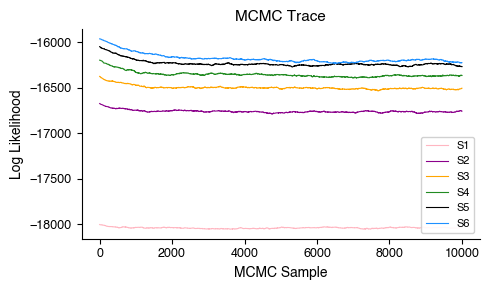

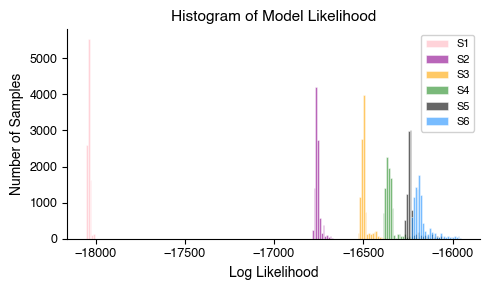


Saved: mcmc_trace.pdf
Saved: mcmc_histogram.pdf


In [27]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

# ─── SET BEFORE ANYTHING ELSE ────────────────
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
N_S_max           = 6
N_iterations_MCMC = 100000   # update to match your actual number
BIN_WIDTH         = 10       # adjust based on your log likelihood range

SUBTYPE_COLORS = [
    "#FFB6C1",   # pink   (S1)
    "#8B008B",   # purple (S2)
    "#FFA500",   # orange (S3)
    "#228B22",   # green  (S4)
    "#000000",   # black  (S5)
    "#1E90FF",   # blue   (S6)
]

FIGSIZE = (5, 3)   # both figures use the same size

# ─────────────────────────────────────────────
# CREATE FIGURES
# ─────────────────────────────────────────────
fig0, ax0 = plt.subplots(figsize=FIGSIZE)   # MCMC trace
fig1, ax1 = plt.subplots(figsize=FIGSIZE)   # Likelihood histogram

# ─────────────────────────────────────────────
# LOOP THROUGH SUBTYPES
# ─────────────────────────────────────────────
for s in range(N_S_max):
    pickle_filename_s = (output_folder + '/pickle_files/' +
                         dataset_name + '_subtype' + str(s) + '.pickle')
    pickle_filepath = Path(pickle_filename_s)

    if not pickle_filepath.exists():
        print(f"Warning: file not found for S{s+1}: {pickle_filename_s}")
        continue

    with open(pickle_filename_s, 'rb') as pickle_file:
        loaded_variables   = pickle.load(pickle_file)
        samples_likelihood = loaded_variables["samples_likelihood"]

    label = f"S{s+1}"

    # Print range to help tune BIN_WIDTH
    print(f"S{s+1} likelihood — "
          f"min: {samples_likelihood.min():.2f}, "
          f"max: {samples_likelihood.max():.2f}, "
          f"range: {samples_likelihood.max() - samples_likelihood.min():.2f}")

    # --- MCMC trace ---
    ax0.plot(
        range(len(samples_likelihood)),
        samples_likelihood,
        label=label,
        color=SUBTYPE_COLORS[s],
        linewidth=0.8,
        alpha=1
    )

    # --- Likelihood histogram with fixed bin width ---
    bins = np.arange(
        samples_likelihood.min(),
        samples_likelihood.max() + BIN_WIDTH,
        BIN_WIDTH
    )
    ax1.hist(
        samples_likelihood,
        bins=bins,
        label=label,
        color=SUBTYPE_COLORS[s],
        alpha=0.6,
        edgecolor="white",
        linewidth=0.5
    )

# ─────────────────────────────────────────────
# FORMAT TRACE PLOT
# ─────────────────────────────────────────────
ax0.set_xlabel("MCMC Sample", fontsize=10)
ax0.set_ylabel("Log Likelihood", fontsize=10)
ax0.set_title("MCMC Trace", fontsize=11)
ax0.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax0.spines[["top", "right"]].set_visible(False)
ax0.tick_params(labelsize=9)

# ─────────────────────────────────────────────
# FORMAT HISTOGRAM PLOT
# ─────────────────────────────────────────────
ax1.set_xlabel("Log Likelihood", fontsize=10)
ax1.set_ylabel("Number of Samples", fontsize=10)
ax1.set_title("Histogram of Model Likelihood", fontsize=11)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(labelsize=9)

# ─────────────────────────────────────────────
# SAVE AS EDITABLE PDF
# ─────────────────────────────────────────────
fig0.tight_layout()
fig1.tight_layout()

fig0.savefig("mcmc_trace.pdf",     bbox_inches="tight", format="pdf")
fig1.savefig("mcmc_histogram.pdf", bbox_inches="tight", format="pdf")

plt.show()
print("\nSaved: mcmc_trace.pdf")
print("Saved: mcmc_histogram.pdf")


---
## 7 · Cross-Validation — Selecting the Optimal Number of Subtypes

We use **stratified k-fold cross-validation** (k = 3) to select the number of subtypes that generalises best to held-out data. The **Cross-Validation Information Criterion (CVIC)** combines log-likelihood on the test set with a complexity penalty. The subtype model with the *lowest* CVIC is preferred.

The stratification label distinguishes controls from cases, ensuring each fold contains a representative proportion of both.


In [28]:
# Define stratification labels: 0 = control, 1 = case
labels = np.ones(data.shape[0], dtype=int)
labels[index_control] = 0

# Generate stratified 3-fold splits
N_folds = 3
cv     = sklearn.model_selection.StratifiedKFold(n_splits=N_folds, shuffle=True, random_state=42)
test_idxs = [test for _, test in cv.split(data, labels)]

print(f"Fold sizes: {[len(t) for t in test_idxs]}")


Fold sizes: [99, 99, 98]


In [29]:
# Run cross-validation — writes per-fold pickle files
CVIC, loglike_matrix = sustain_input.cross_validate_sustain_model(test_idxs)

print("CVIC per subtype model:")
for s, cvic in enumerate(CVIC):
    print(f"  {s+1} subtype(s): CVIC = {cvic:.2f}")



Folds:   0%|          | 0/3 [00:00<?, ?it/s]

Loading /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red/pickle_files/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red_fold0_subtype0.pickle
Loading /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red/pickle_files/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red_fold0_subtype1.pickle
Loading /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red/pickle_files/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardized-net-brown-red_fold0_subtype2.pickle
Loading /Users/shivaafshar/Library/CloudStorage/OneDrive-EmoryUniversity/Research-Shiva/somascan_new_project/FNIH-CSF-eigen-PC-5-normalized-cleanCT-unstandardiz

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


S1 likelihood — min: -18054.07, max: -18002.91, range: 51.15
S2 likelihood — min: -16788.68, max: -16672.28, range: 116.40
S3 likelihood — min: -16532.56, max: -16373.67, range: 158.90
S4 likelihood — min: -16391.97, max: -16195.18, range: 196.79
S5 likelihood — min: -16270.17, max: -16046.31, range: 223.86
S6 likelihood — min: -16231.15, max: -15960.66, range: 270.49

CVIC for each subtype model: [36435.12760097 33770.99705483 33394.84004549 33241.4827435
 33058.34403389 32998.7164772 ]
Average test set log-likelihood: [-5025.02186407 -5021.12464833 -5019.48626576 -5012.07826191
 -5004.58095679 -5004.27843384]


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


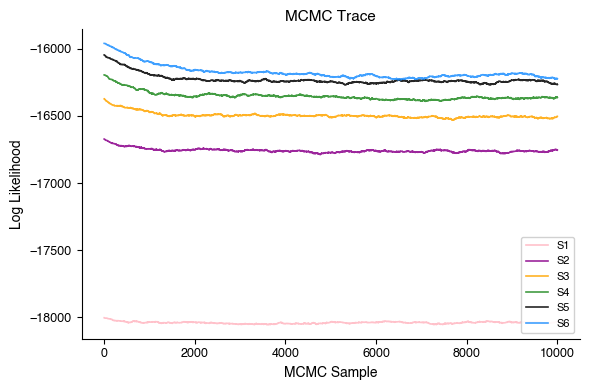

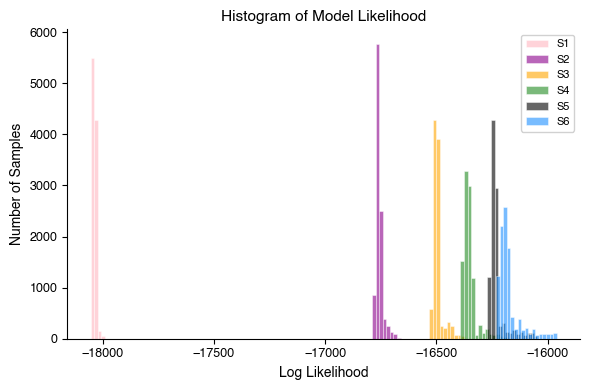

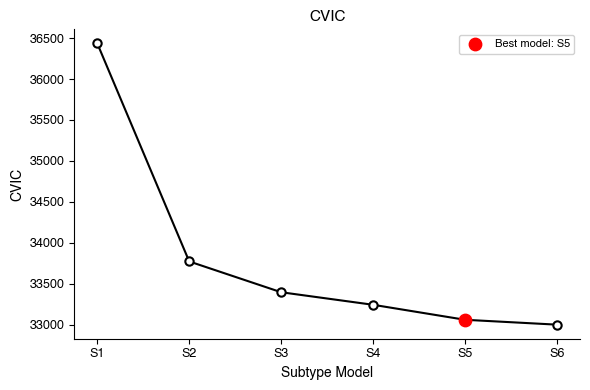


Saved: mcmc_trace.pdf
Saved: mcmc_histogram.pdf
Saved: cvic.pdf
Saved: test_loglikelihood.pdf


In [33]:
# ─── SET BEFORE ANYTHING ELSE ────────────────
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
N_S_max           = 6
N_iterations_MCMC = 100000   # update to match your actual number
BIN_WIDTH         = 16       # adjust based on your log likelihood range

SUBTYPE_COLORS = [
    "#FFB6C1",   # pink   (S1)
    "#8B008B",   # purple (S2)
    "#FFA500",   # orange (S3)
    "#228B22",   # green  (S4)
    "#000000",   # black  (S5)
    "#1E90FF",   # blue   (S6)
]

FIGSIZE = (6, 4)   # all figures use the same size

# ─────────────────────────────────────────────
# CREATE ALL FOUR FIGURES
# ─────────────────────────────────────────────
fig0, ax0 = plt.subplots(figsize=FIGSIZE)   # MCMC trace
fig1, ax1 = plt.subplots(figsize=FIGSIZE)   # Likelihood histogram
fig2, ax2 = plt.subplots(figsize=FIGSIZE)   # CVIC
#fig3, ax3 = plt.subplots(figsize=FIGSIZE)   # Test set log-likelihood boxplot

# ─────────────────────────────────────────────
# LOOP THROUGH SUBTYPES — MCMC trace + histogram
# ─────────────────────────────────────────────
for s in range(N_S_max):
    pickle_filename_s = (output_folder + '/pickle_files/' +
                         dataset_name + '_subtype' + str(s) + '.pickle')
    pickle_filepath = Path(pickle_filename_s)

    if not pickle_filepath.exists():
        print(f"Warning: file not found for S{s+1}: {pickle_filename_s}")
        continue

    with open(pickle_filename_s, 'rb') as pickle_file:
        loaded_variables   = pickle.load(pickle_file)
        samples_likelihood = loaded_variables["samples_likelihood"]

    label = f"S{s+1}"

    # Print range to help tune BIN_WIDTH
    print(f"S{s+1} likelihood — "
          f"min: {samples_likelihood.min():.2f}, "
          f"max: {samples_likelihood.max():.2f}, "
          f"range: {samples_likelihood.max() - samples_likelihood.min():.2f}")

    # --- MCMC trace ---
    ax0.plot(
        range(len(samples_likelihood)),
        samples_likelihood,
        label=label,
        color=SUBTYPE_COLORS[s],
        linewidth=1.2,
        alpha=0.85
    )

    # --- Likelihood histogram with fixed bin width ---
    bins = np.arange(
        samples_likelihood.min(),
        samples_likelihood.max() + BIN_WIDTH,
        BIN_WIDTH
    )
    ax1.hist(
        samples_likelihood,
        bins=bins,
        label=label,
        color=SUBTYPE_COLORS[s],
        alpha=0.6,
        edgecolor="white",
        linewidth=0.5
    )

# ─────────────────────────────────────────────
# FORMAT TRACE PLOT (fig0)
# ─────────────────────────────────────────────
ax0.set_xlabel("MCMC Sample", fontsize=10)
ax0.set_ylabel("Log Likelihood", fontsize=10)
ax0.set_title("MCMC Trace", fontsize=11)
ax0.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax0.spines[["top", "right"]].set_visible(False)
ax0.tick_params(labelsize=9)

# ─────────────────────────────────────────────
# FORMAT HISTOGRAM PLOT (fig1)
# ─────────────────────────────────────────────
ax1.set_xlabel("Log Likelihood", fontsize=10)
ax1.set_ylabel("Number of Samples", fontsize=10)
ax1.set_title("Histogram of Model Likelihood", fontsize=11)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(labelsize=9)

# ─────────────────────────────────────────────
# CVIC PLOT (fig2)
# ─────────────────────────────────────────────
print("\nCVIC for each subtype model: " + str(CVIC))
print("Average test set log-likelihood: " + str(np.mean(loglike_matrix, 0)))

ax2.plot(
    np.arange(1, N_S_max + 1, dtype=int),
    CVIC,
    color="black",
    linewidth=1.5,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.5
)

# Highlight minimum CVIC (best model)
best_s = 4
ax2.scatter(
    best_s + 1, CVIC[best_s],
    color="red", s=80, zorder=5,
    label=f"Best model: S{best_s+1}"
)

ax2.set_xticks(np.arange(1, N_S_max + 1, dtype=int))
ax2.set_xticklabels([f"S{s+1}" for s in range(N_S_max)], fontsize=9)
ax2.set_xlabel("Subtype Model", fontsize=10)
ax2.set_ylabel("CVIC", fontsize=10)
ax2.set_title("CVIC", fontsize=11)
ax2.legend(fontsize=8, framealpha=0.9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(labelsize=9)


# ─────────────────────────────────────────────
# SAVE ALL AS EDITABLE PDF
# ─────────────────────────────────────────────
fig0.tight_layout()
fig1.tight_layout()
fig2.tight_layout()
#fig3.tight_layout()

fig0.savefig("mcmc_trace.pdf",          bbox_inches="tight", format="pdf")
fig1.savefig("mcmc_histogram.pdf",      bbox_inches="tight", format="pdf")
fig2.savefig("cvic.pdf",                bbox_inches="tight", format="pdf")
#fig3.savefig("test_loglikelihood.pdf",  bbox_inches="tight", format="pdf")

plt.show()
print("\nSaved: mcmc_trace.pdf")
print("Saved: mcmc_histogram.pdf")
print("Saved: cvic.pdf")
print("Saved: test_loglikelihood.pdf")

---
## 8 · Subtype Assignment

Using the **5-subtype model** selected by cross-validation, we assign each subject to their most likely subtype and stage by pooling assignments across cross-validation folds (ensuring each subject was in the held-out set exactly once).

Output: `SuStaIn_subtypes_prob.csv` — a 296 × 5 table of per-subject subtype probabilities.


In [46]:
N_S_gt=5 # optimal number of subtypes
s = N_S_gt-1

Nfolds                              = 3#len(test_idxs)
for fold in range(Nfolds):
    pickle_filename_fold_s  = sustain_input.output_folder + '/pickle_files/' + sustain_input.dataset_name + '_fold' + str(fold) + '_subtype' + str(s) + '.pickle'
    pickle_filepath         = Path(pickle_filename_fold_s)

    pickle_file             = open(pickle_filename_fold_s, 'rb')

    loaded_variables        = pickle.load(pickle_file)

    samples_sequence        = loaded_variables["samples_sequence"]
    samples_f               = loaded_variables["samples_f"]
    
    pickle_file.close()
    
    if fold == 0:
        samples_sequence_cval    = samples_sequence
        samples_f_cval           = samples_f
    else:
        samples_sequence_cval    = np.concatenate((samples_sequence_cval, samples_sequence), axis=2)
        samples_f_cval           = np.concatenate((samples_f_cval, samples_f), axis=1)
                    
N_samples                       =1000
ml_subtype_cval,             \
prob_ml_subtype_cval,        \
ml_stage_cval,               \
prob_ml_stage_cval,          \
prob_subtype_cval,           \
prob_stage_cval,             \
prob_subtype_stage_cval          = sustain_input.subtype_and_stage_individuals_newData(data,
                                                                                       samples_sequence_cval,
                                                                                       samples_f_cval,
                                                                                       N_samples)
prob_subtype_cval_df=pd.DataFrame(prob_subtype_cval)

prob_subtype_cval_df.columns=["subtype 1","subtype 2","subtype 3","subtype 4","subtype 5"]
prob_subtype_cval_df.index=samples
prob_subtype_cval_df.to_csv("SuStaIn_subtypes_prob.csv")

In [47]:
# Load the full-model (non-CV) subtype assignments for downstream visualisation
pickle_path_full = output_folder + '/pickle_files/' + dataset_name + f'_subtype{s}.pickle'
with open(pickle_path_full, 'rb') as f:
    loaded_full = pickle.load(f)

ml_subtype       = loaded_full["ml_subtype"]
prob_ml_subtype  = loaded_full["prob_ml_subtype"]
ml_stage         = loaded_full["ml_stage"]
prob_ml_stage    = loaded_full["prob_ml_stage"]
prob_subtype_stage = loaded_full["prob_subtype_stage"]
samples_sequence = loaded_full["samples_sequence"]
samples_f        = loaded_full["samples_f"]

print(f"Full-model assignments loaded for {len(ml_subtype)} subjects.")


Full-model assignments loaded for 296 subjects.


---
## 9 · Subtype Probability Simplex (Pentagon Plot)

The **pentagon simplex** visualises each subject's uncertainty across 5 subtypes. Each vertex represents one subtype, and each subject is plotted at the weighted centroid of their subtype probabilities. Subjects confidently assigned to a single subtype cluster near the corresponding vertex; uncertain subjects appear towards the centre.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Loaded: 296 subjects, 5 subtypes

─── Subtype Assignment Summary ───────────────────────────
Subtype           N        %     Mean prob    Min prob    Max prob
─────────────────────────────────────────────────────────────────
S1               96    32.4%         0.598       0.281       0.947
S2               82    27.7%         0.488       0.285       0.954
S3               75    25.3%         0.737       0.257       1.000
S4               17     5.7%         0.479       0.334       0.638
S5               26     8.8%         0.688       0.383       0.992
─────────────────────────────────────────────────────────────────
Total           296   100.0%


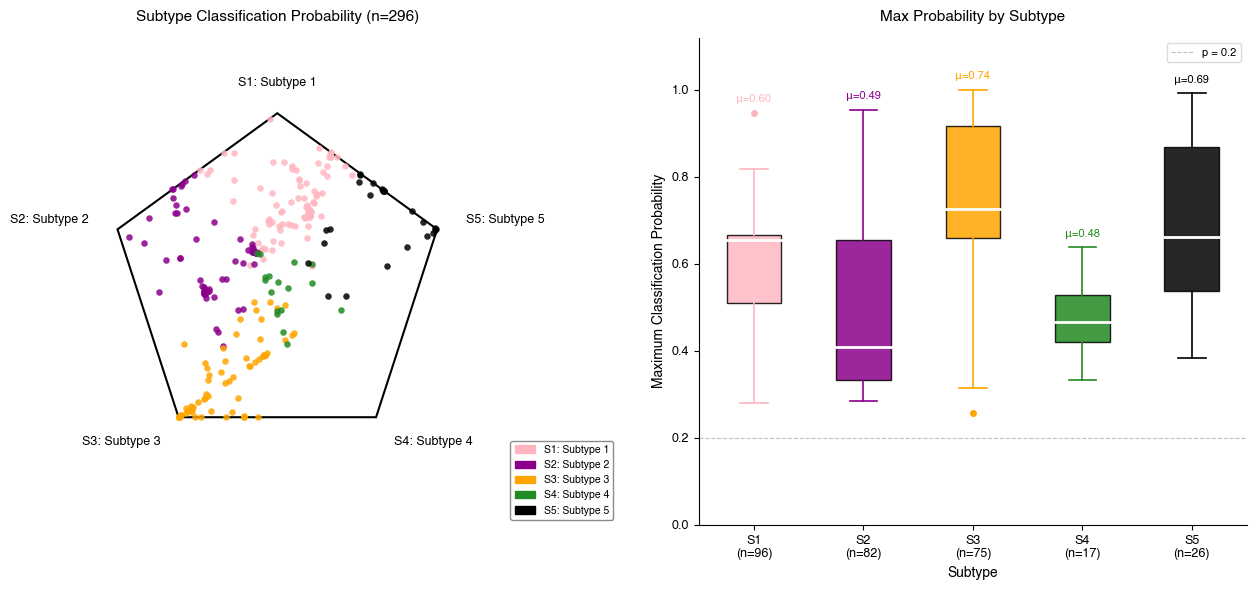


Saved: pentagon_and_boxplot.png
Saved: subtype_assignments.csv


In [56]:
"""
Pentagon Simplex Plot + Boxplot for SuStaIn 5-Subtype Classification Probabilities
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
# AFTER:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42      # makes fonts editable in Illustrator/Inkscape
matplotlib.rcParams['ps.fonttype']  = 42      # same for PostScript
# ─────────────────────────────────────────────
# 1.  CONFIGURATION
# ─────────────────────────────────────────────
SUBTYPE_LABELS = [
    "S1: Subtype 1",
    "S2: Subtype 2",
    "S3: Subtype 3",
    "S4: Subtype 4",
    "S5: Subtype 5",
]

SUBTYPE_COLORS = [
    "#FFB6C1",   # pink   (S1)
    "#8B008B",   # purple (S2)
    "#FFA500",   # orange (S3)
    "#228B22",   # green  (S4)
    "#000000",   # black  (S5)
]

# ─────────────────────────────────────────────
# 2.  LOAD DATA
# ─────────────────────────────────────────────
prob_matrix = pd.read_csv("SuStaIn_subtypes_prob.csv", index_col=0)
subject_ids = prob_matrix.index
prob_matrix_np = prob_matrix.values

print(f"Loaded: {prob_matrix_np.shape[0]} subjects, {prob_matrix_np.shape[1]} subtypes")
assert prob_matrix_np.shape[1] == 5, "Expected 5 subtypes"
assert np.allclose(prob_matrix_np.sum(axis=1), 1, atol=1e-6), "Rows must sum to 1"

# ─────────────────────────────────────────────
# 3.  SUBTYPE ASSIGNMENT
# ─────────────────────────────────────────────
dominant_idx   = np.argmax(prob_matrix_np, axis=1)
dominant_prob  = np.max(prob_matrix_np, axis=1)
dominant_label = [f"S{s+1}" for s in dominant_idx]

assignments = pd.DataFrame({
    "SubjectID"      : subject_ids,
    "Subtype"        : dominant_label,
    "Subtype_idx"    : dominant_idx + 1,
    "Max_probability": dominant_prob,
})
assignments.set_index("SubjectID", inplace=True)

# ─────────────────────────────────────────────
# 4.  PRINT SUMMARY
# ─────────────────────────────────────────────
print("\n─── Subtype Assignment Summary ───────────────────────────")
print(f"{'Subtype':<12} {'N':>6} {'%':>8}  {'Mean prob':>12}  "
      f"{'Min prob':>10}  {'Max prob':>10}")
print("─" * 65)
for s in range(5):
    label  = f"S{s+1}"
    mask   = dominant_idx == s
    n      = mask.sum()
    pct    = 100 * n / len(dominant_idx)
    mean_p = dominant_prob[mask].mean() if n > 0 else 0
    min_p  = dominant_prob[mask].min()  if n > 0 else 0
    max_p  = dominant_prob[mask].max()  if n > 0 else 0
    print(f"{label:<12} {n:>6} {pct:>7.1f}%  {mean_p:>12.3f}  "
          f"{min_p:>10.3f}  {max_p:>10.3f}")
print("─" * 65)
print(f"{'Total':<12} {len(dominant_idx):>6} {'100.0%':>8}")

# ─────────────────────────────────────────────
# 5.  PENTAGON COORDINATES + PROJECTION
# ─────────────────────────────────────────────
n_subtypes = 5
angles  = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, n_subtypes, endpoint=False)
corners = np.column_stack([np.cos(angles), np.sin(angles)])
coords  = prob_matrix_np @ corners   # (296, 5) @ (5, 2) → (296, 2)

# ─────────────────────────────────────────────
# 6.  FIGURE — pentagon (left) + boxplot (right)
# ─────────────────────────────────────────────
fig, (ax_pent, ax_box) = plt.subplots(
    1, 2,
    figsize=(13, 6),
    gridspec_kw={"width_ratios": [1, 1]}
)

# ════════════════════════════════════════════
# LEFT: Pentagon simplex plot
# ════════════════════════════════════════════

# --- Outer pentagon ---
outer_pentagon = Polygon(corners, closed=True, fill=False,
                         edgecolor="black", linewidth=1.5, zorder=2)
ax_pent.add_patch(outer_pentagon)

# --- Scatter: subjects coloured by dominant subtype ---
for s in range(n_subtypes):
    idx = dominant_idx == s
    ax_pent.scatter(
        coords[idx, 0], coords[idx, 1],
        color=SUBTYPE_COLORS[s], s=22, alpha=0.85,
        zorder=3, linewidths=0, label=SUBTYPE_LABELS[s]
    )

# --- Corner labels ---
label_offsets = corners * 1.18
for i, (lbl, pos) in enumerate(zip(SUBTYPE_LABELS, label_offsets)):
    ha = "center"
    if pos[0] < -0.1: ha = "right"
    elif pos[0] > 0.1: ha = "left"
    ax_pent.text(pos[0], pos[1], lbl, ha=ha, va="center",
                 fontsize=9, fontweight="bold")

# --- Legend ---
handles = [mpatches.Patch(color=SUBTYPE_COLORS[s], label=SUBTYPE_LABELS[s])
           for s in range(n_subtypes)]
# AFTER:
ax_pent.legend(handles=handles, loc="lower right", fontsize=7.5,
               framealpha=0.9, edgecolor="grey",
               bbox_to_anchor=(1.2, 0.0))

ax_pent.set_xlim(-1.45, 1.45)
ax_pent.set_ylim(-1.45, 1.45)
ax_pent.set_aspect("equal")
ax_pent.axis("off")
ax_pent.set_title(f"Subtype Classification Probability (n={len(dominant_idx)})",
                  fontsize=11, pad=12)

# ════════════════════════════════════════════
# RIGHT: Boxplot of max probabilities per subtype
# ════════════════════════════════════════════

# Collect max_prob per subtype
prob_by_subtype = [dominant_prob[dominant_idx == s] for s in range(n_subtypes)]
counts          = [len(p) for p in prob_by_subtype]

bp = ax_box.boxplot(
    prob_by_subtype,
    patch_artist=True,
    notch=False,
    widths=0.5,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=4, linestyle="none"),
)

# Colour each box and outliers by subtype
for s, (patch, flier) in enumerate(zip(bp["boxes"], bp["fliers"])):
    patch.set_facecolor(SUBTYPE_COLORS[s])
    patch.set_alpha(0.85)
    flier.set_markerfacecolor(SUBTYPE_COLORS[s])
    flier.set_markeredgecolor(SUBTYPE_COLORS[s])

# Colour whiskers and caps
for s in range(n_subtypes):
    for element in ["whiskers", "caps"]:
        # Each subtype has 2 whiskers and 2 caps
        bp[element][s * 2].set_color(SUBTYPE_COLORS[s])
        bp[element][s * 2 + 1].set_color(SUBTYPE_COLORS[s])

# --- x-axis labels with sample size ---
ax_box.set_xticks(range(1, n_subtypes + 1))
ax_box.set_xticklabels(
    [f"S{s+1}\n(n={counts[s]})" for s in range(n_subtypes)],
    fontsize=9
)

# --- Annotate mean prob above each box ---
for s, probs in enumerate(prob_by_subtype):
    if len(probs) > 0:
        ax_box.text(s + 1, probs.max() + 0.02,
                    f"μ={probs.mean():.2f}",
                    ha="center", va="bottom",
                    fontsize=8, color=SUBTYPE_COLORS[s],
                    fontweight="bold")

ax_box.set_ylabel("Maximum Classification Probability", fontsize=10)
ax_box.set_xlabel("Subtype", fontsize=10)
ax_box.set_title("Max Probability by Subtype", fontsize=11, pad=12)
ax_box.set_ylim(0, 1.12)
ax_box.spines[["top", "right"]].set_visible(False)
ax_box.tick_params(axis="y", labelsize=9)
ax_box.axhline(y=0.2, color="grey", linewidth=0.8,
               linestyle="--", alpha=0.5, label="p = 0.2")
ax_box.legend(fontsize=8, framealpha=0.7)

# ─────────────────────────────────────────────
# 7.  SAVE
# ─────────────────────────────────────────────
plt.tight_layout()
plt.savefig("pentagon_and_boxplot.pdf", 
            bbox_inches="tight",
            format="pdf",
            transparent=False)
plt.show()
print("\nSaved: pentagon_and_boxplot.png")

assignments.to_csv("subtype_assignments.csv")
print("Saved: subtype_assignments.csv")

---
## Comparison with Alternative Clustering Methods

To benchmark SuStaIn against simpler approaches, we apply k-means, hierarchical (agglomerative) clustering, and non-negative matrix factorisation (NMF) to the same 33 module eigengene matrix.

Agreement with SuStaIn is quantified by **Adjusted Rand Index (ARI)** and **Normalised Mutual Information (NMI)**.

> These analyses are not part of the primary results but are reported in the supplementary materials to demonstrate the added value of SuStaIn's stage-aware subtyping.


In [80]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import NMF
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import scipy.cluster.hierarchy as sch
import nimfa

new_data = pd.read_excel(
    "FNIH296CSF-cleanDat.MEs.ModuleAssignments.Traits_forTraining_withShiva(EBD).xlsb", 
    sheet_name="MEs(34modules)", 
    engine='pyxlsb'
)
new_data.index = new_data.iloc[:, 0]
new_data = new_data.iloc[:, 1:]
new_data = new_data.T
new_data = new_data.drop(columns=['turquoise'])
# Use the same preprocessed data as SuStaIn
X = new_data.values   # (296, 33) z-scored module eigengenes
N_clusters = 5   # match SuStaIn's 5 subtypes
sustain_labels = np.concatenate(ml_subtype_cval.astype(int))

results_comparison = {}

# ── K-means ──────────────────────────────────────────────────────────────────
km = KMeans(n_clusters=N_clusters, random_state=42)
km_labels = km.fit_predict(X)
results_comparison['K-means'] = {
    'labels': km_labels,
    'ARI': adjusted_rand_score(sustain_labels, km_labels),
    'NMI': normalized_mutual_info_score(sustain_labels, km_labels),
}

# ── Hierarchical clustering ───────────────────────────────────────────────────
hc = AgglomerativeClustering(n_clusters=N_clusters,linkage='ward' )
hc_labels = hc.fit_predict(X)
results_comparison['Hierarchical'] = {
    'labels': hc_labels,
    'ARI': adjusted_rand_score(sustain_labels, hc_labels),
    'NMI': normalized_mutual_info_score(sustain_labels, hc_labels),
}

# ── NMF ──────────────────────────────────────────────────────────────────────
scaled_data = (new_data - new_data.min()) / (new_data.max() - new_data.min())
scaled_data = scaled_data * (2 - 1) + 1  # scale to [1, 2]
X=scaled_data.values
# Suppose V is your input data matrix (samples x features)
# e.g., V = np.random.rand(100, 200)
np.random.seed(42)
nsnmf = nimfa.Nsnmf(X, rank=5, theta=0.5, max_iter=2000,seed="nndsvd")
fit = nsnmf()

W = fit.basis()      # Cluster assignments (samples x rank)
H = fit.coef()       # Metagenes (rank x features)
nmf_labels = np.concatenate(np.array(np.argmax(W, axis=1)))
results_comparison['NMF'] = {
    'labels': nmf_labels,
    'ARI': adjusted_rand_score(sustain_labels, nmf_labels),
    'NMI': normalized_mutual_info_score(sustain_labels, nmf_labels),
}

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    method: {'ARI': v['ARI'], 'NMI': v['NMI']}
    for method, v in results_comparison.items()
}).T.round(3)

print("Agreement with SuStaIn (5 subtypes):")
display(summary)


Agreement with SuStaIn (5 subtypes):


,ARI,NMI
K-means,0.175,0.274
Hierarchical,0.139,0.221
NMF,0.188,0.261


SUBTYPE COMPARISON ANALYSIS - COMPLETE REVISED VERSION 3.0

[1/7] Loading data...
   ✓ Loaded 296 samples
   ✓ Prepared 6 subtyping methods

[2/7] Computing agreement metrics...
   ✓ Saved: method_agreement_ARI.csv
   ✓ Saved: method_agreement_NMI.csv

   Adjusted Rand Index (ARI) - Agreement Matrix:
   ---------------------------------------------------------------------------
   SuStaIn: 5 subtypes                           |  ---   0.125  0.175  0.188  0.145  0.146 
   Monet.M1: 3 subtypes                          | 0.125   ---   0.341  0.121  0.519  0.260 
   Kmeans: 5 subtypes                            | 0.175  0.341   ---   0.221  0.277  0.259 
   NMF: 5 subtypes                               | 0.188  0.121  0.221   ---   0.137  0.185 
   Hierarchical clustering: 5 subtypes           | 0.145  0.519  0.277  0.137   ---   0.271 
   WGCNA: 11 subtypes                            | 0.146  0.260  0.259  0.185  0.271   ---  

   Top 5 Most Similar Method Pairs:
   #1: Monet.M1         

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


   ✓ Saved: FNIH_method_agreement_heatmap.pdf/.png

[6/7] Creating consensus score distribution...
   ✓ Saved: FNIH_consensus_score_distribution.pdf/.png

[7/7] Creating main comparison heatmap...
   Processing panel sorted by SuStaIn subtypes...
   Processing panel sorted by MONET.M1...
   Processing panel sorted by Kmeans...
   Processing panel sorted by NMF...
   Processing panel sorted by Hierarchical clustering...
   Processing panel sorted by WGCNA...

   Saving main heatmap...


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


   ✓ Saved: FNIH_all_methods_heatmap.pdf/.png


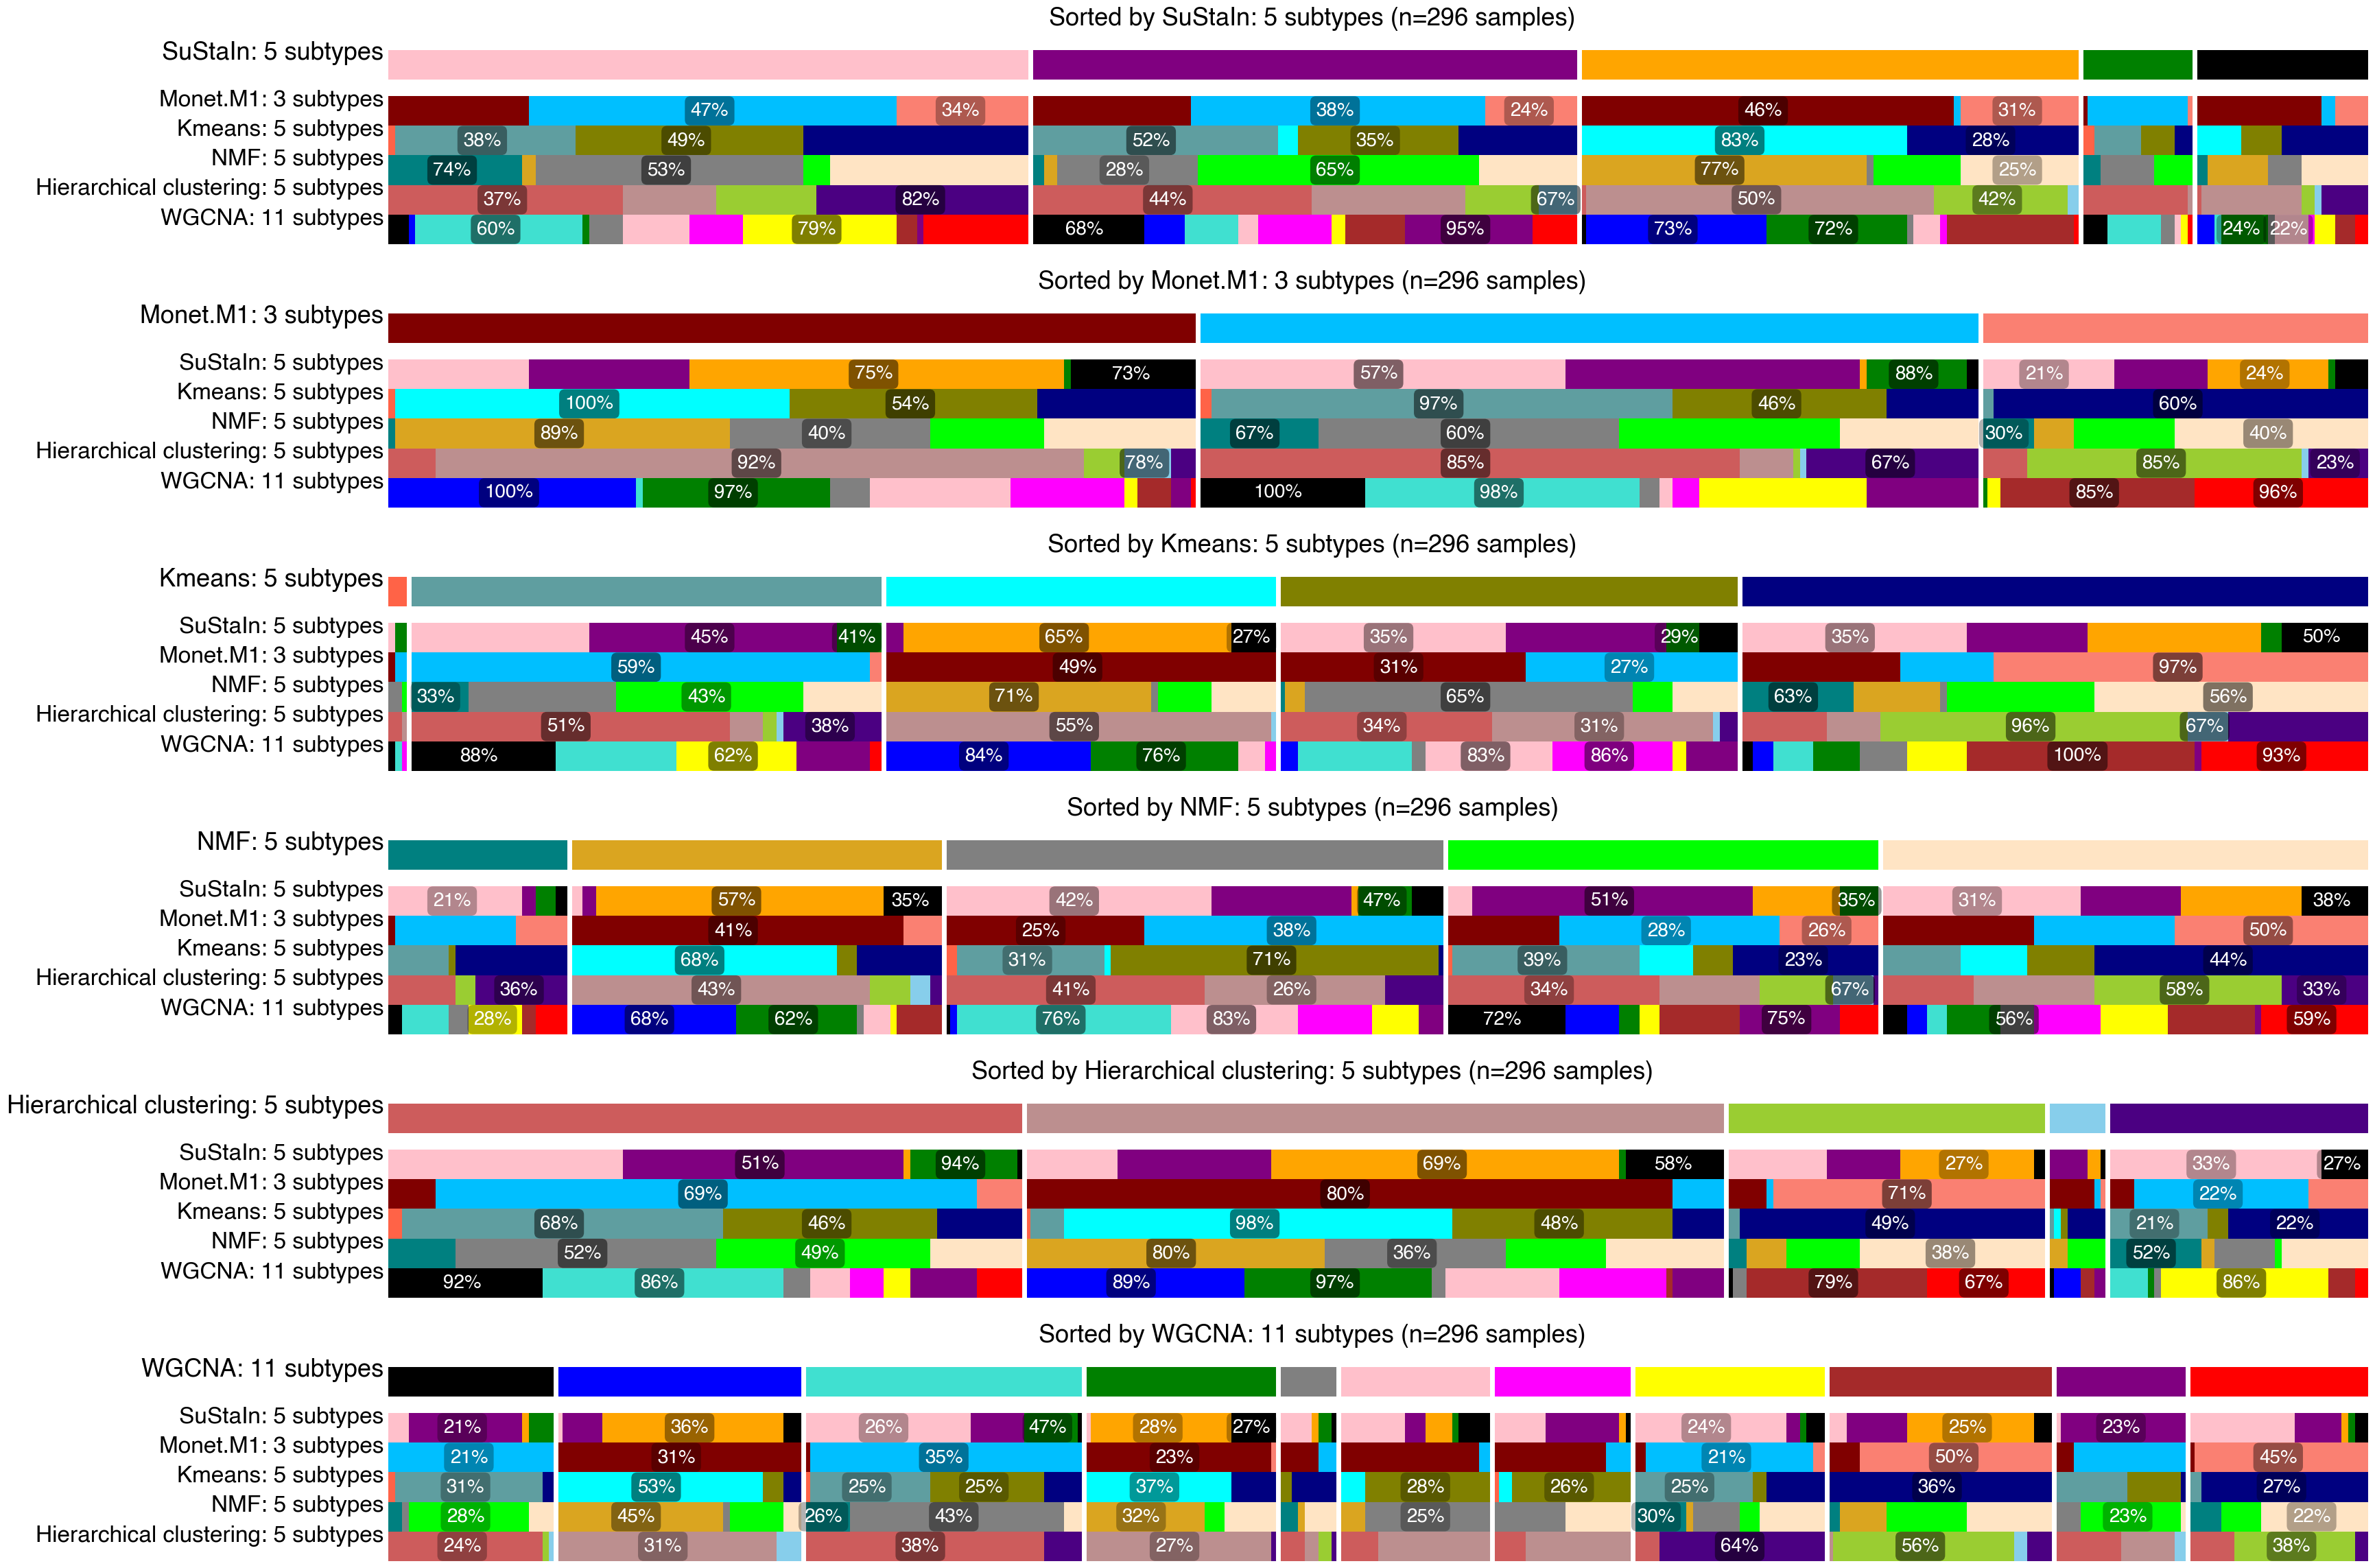


ANALYSIS COMPLETE - SUMMARY

1. FILES GENERATED:
   - method_agreement_ARI.csv
   - method_agreement_NMI.csv
   - subtype_size_summary.csv
   - ambiguous_samples.csv
   - FNIH_method_agreement_heatmap.pdf/.png
   - FNIH_consensus_score_distribution.pdf/.png
   - FNIH_all_methods_heatmap.pdf/.png (+ highres)

2. KEY STATISTICS:
   - Total samples: 296
   - Methods compared: 6
   - Mean ARI (excluding diagonal): 0.225
   - Ambiguous samples: 29 (9.8%)

3. TOP AGREEMENTS:
   #1: Monet.M1 ↔ Hierarchical clustering (ARI = 0.519)
   #2: Monet.M1 ↔ Kmeans (ARI = 0.341)
   #3: Kmeans ↔ Hierarchical clustering (ARI = 0.277)

All outputs ready for publication!



In [76]:
#!/usr/bin/env python3
"""
SUBTYPE COMPARISON ANALYSIS - COMPLETE REVISED VERSION
=======================================================

Comprehensive comparison of multiple subtyping methods with:
- Quantitative agreement metrics (ARI, NMI)
- Visual comparison heatmaps
- Consensus score analysis
- Publication-ready figures

Author: Enhanced Analysis Suite
Version: 3.0 - Complete Revision
Date: February 2026
"""

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("="*80)
print("SUBTYPE COMPARISON ANALYSIS - COMPLETE REVISED VERSION 3.0")
print("="*80)

# ============================================================================
# SECTION 1: DATA LOADING
# ============================================================================

print("\n[1/7] Loading data...")

try:
    data1 = pd.read_excel(
        "FNIH296CSF-cleanDat.MEs.ModuleAssignments.Traits_forTraining_withShiva(EBD).xlsb",
        sheet_name="SUSTAIN.numericMeta-Stage+Subty",
        engine='pyxlsb'
    )
    data1.index = data1.iloc[:, 0]
    data1 = data1.iloc[:, 1:]
    print(f"   ✓ Loaded {len(data1)} samples")
except Exception as e:
    print(f"   ✗ Error: {e}")
    print("   Ensure Excel file is in current directory")
    exit(1)

df = pd.DataFrame({
    "WGCNA": data1["WGCNA-unstandardized-net"],
    "SuStaIn subtypes": data1["subtype_sustain_FNIH_33_eigenprotein_5_unstandardized_rbCT"],
    "MONET.M1": data1["MONET.M1(3-150-75)-33-normalized"],
    "NMF": data1["nmf_subtypes_33_eigenproteins_5_scaled1-2"],
    "Kmeans": data1["kmeans_subtypes_33_eigenproteins_5"],
    "Hierarchical clustering": data1["hc_subtypes_33_eigenproteins_5"],
    "SuStaIn stages": data1["stage_sustain_FNIH_33_eigenprotein_5_unstandardized_rbCT"]
})

color_mapping = {
    'black': 0, 'blue': 1, 'turquoise': 2, 'green': 3, 'grey': 4,
    'pink': 5, 'magenta': 6, 'yellow': 7, 'brown': 8,
    'purple': 9, 'red': 10
}
df['WGCNA'] = df['WGCNA'].map(color_mapping)

print(f"   ✓ Prepared {len(df.columns)-1} subtyping methods")

# ============================================================================
# SECTION 2: METHOD CONFIGURATION
# ============================================================================

methods = ["SuStaIn subtypes", "MONET.M1", "Kmeans", "NMF",
           "Hierarchical clustering", "WGCNA"]

method_labels = {
    "SuStaIn subtypes": "SuStaIn: 5 subtypes",
    "MONET.M1": "Monet.M1: 3 subtypes",
    "Kmeans": "Kmeans: 5 subtypes",
    "NMF": "NMF: 5 subtypes",
    "Hierarchical clustering": "Hierarchical clustering: 5 subtypes",
    "WGCNA": "WGCNA: 11 subtypes"
}

colormaps = {
    "MONET.M1": ListedColormap(['maroon', 'beige', 'deepskyblue', 'tan', 'salmon']),
    "SuStaIn subtypes": ListedColormap(['pink', 'purple', 'orange', 'green', "black"]),
    "Kmeans": ListedColormap(['tomato', 'cadetblue', 'cyan', 'olive', 'navy']),
    "NMF": ListedColormap(['teal', 'goldenrod', 'gray', 'lime', 'bisque']),
    "Hierarchical clustering": ListedColormap(['indianred', 'rosybrown',
                                               'yellowgreen', 'skyblue', 'indigo']),
    "WGCNA": ListedColormap([
        'black', 'blue', 'turquoise', 'green', 'grey',
        'pink', 'magenta', 'yellow', 'brown', 'purple', 'red'
    ])
}

# ============================================================================
# SECTION 3: QUANTITATIVE AGREEMENT METRICS
# ============================================================================

print("\n[2/7] Computing agreement metrics...")

agreement_ari = pd.DataFrame(index=methods, columns=methods, dtype=float)
agreement_nmi = pd.DataFrame(index=methods, columns=methods, dtype=float)

for m1 in methods:
    for m2 in methods:
        valid_idx = df[m1].notna() & df[m2].notna()
        if valid_idx.sum() > 0:
            agreement_ari.loc[m1, m2] = adjusted_rand_score(
                df.loc[valid_idx, m1],
                df.loc[valid_idx, m2]
            )
            agreement_nmi.loc[m1, m2] = normalized_mutual_info_score(
                df.loc[valid_idx, m1],
                df.loc[valid_idx, m2]
            )
        else:
            agreement_ari.loc[m1, m2] = np.nan
            agreement_nmi.loc[m1, m2] = np.nan

agreement_ari.to_csv('method_agreement_ARI.csv', float_format='%.3f')
agreement_nmi.to_csv('method_agreement_NMI.csv', float_format='%.3f')
print("   ✓ Saved: method_agreement_ARI.csv")
print("   ✓ Saved: method_agreement_NMI.csv")

print("\n   Adjusted Rand Index (ARI) - Agreement Matrix:")
print("   " + "-"*75)
for m1 in methods:
    row_str = f"   {method_labels[m1]:45s} |"
    for m2 in methods:
        val = agreement_ari.loc[m1, m2]
        if m1 == m2:
            row_str += "  ---  "
        else:
            row_str += f" {val:5.3f} "
    print(row_str)

ari_pairs = []
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i < j:
            ari_pairs.append((m1, m2, agreement_ari.loc[m1, m2]))

ari_pairs.sort(key=lambda x: x[2], reverse=True)

print("\n   Top 5 Most Similar Method Pairs:")
for rank, (m1, m2, ari) in enumerate(ari_pairs[:5], 1):
    m1_short = method_labels[m1].split(':')[0]
    m2_short = method_labels[m2].split(':')[0]
    print(f"   #{rank}: {m1_short:25s} ↔ {m2_short:25s}  ARI = {ari:.3f}")

# ============================================================================
# SECTION 4: SUBTYPE SIZE STATISTICS
# ============================================================================

print("\n[3/7] Calculating subtype size statistics...")

summary_stats = []
for method in methods:
    n_subtypes = df[method].nunique()
    subtype_sizes = df[method].value_counts().sort_index()
    summary_stats.append({
        'Method': method_labels[method],
        'N_subtypes': n_subtypes,
        'Min_size': int(subtype_sizes.min()),
        'Max_size': int(subtype_sizes.max()),
        'Mean_size': subtype_sizes.mean(),
        'Std_size': subtype_sizes.std(),
        'Balance_ratio': subtype_sizes.max() / subtype_sizes.min() if subtype_sizes.min() > 0 else np.nan
    })

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('subtype_size_summary.csv', index=False)
print("   ✓ Saved: subtype_size_summary.csv")

print("\n   Subtype Size Summary:")
print("   " + "-"*90)
print(f"   {'Method':45s} | N_sub | Min  | Max  | Mean  | Std  | Balance")
print("   " + "-"*90)
for _, row in summary_df.iterrows():
    print(f"   {row['Method']:45s} | {row['N_subtypes']:5d} | "
          f"{row['Min_size']:4d} | {row['Max_size']:4d} | "
          f"{row['Mean_size']:5.1f} | {row['Std_size']:4.1f} | "
          f"{row['Balance_ratio']:5.2f}x")

# ============================================================================
# SECTION 5: CONSENSUS SCORE CALCULATION
# ============================================================================

print("\n[4/7] Computing sample-level consensus scores...")

def calculate_sample_consensus(row, methods_list):
    assignments = []
    for m in methods_list:
        val = row[m]
        if pd.notna(val):
            min_val = df[m].min()
            max_val = df[m].max()
            if max_val > min_val:
                normalized = (val - min_val) / (max_val - min_val)
            else:
                normalized = 0.5
            assignments.append(normalized)
    if len(assignments) < 2:
        return np.nan
    variance = np.var(assignments)
    consensus_score = 1 / (1 + variance)
    return consensus_score

df['consensus_score'] = df.apply(
    lambda row: calculate_sample_consensus(row, methods),
    axis=1
)

ambiguous_threshold = df['consensus_score'].quantile(0.10)
df['is_ambiguous'] = df['consensus_score'] < ambiguous_threshold

print(f"   Consensus statistics:")
print(f"      Mean:   {df['consensus_score'].mean():.3f}")
print(f"      Median: {df['consensus_score'].median():.3f}")
print(f"      Std:    {df['consensus_score'].std():.3f}")
print(f"      Range:  {df['consensus_score'].min():.3f} - {df['consensus_score'].max():.3f}")
print(f"\n   Ambiguous samples (< 10th percentile = {ambiguous_threshold:.3f}):")
print(f"      {df['is_ambiguous'].sum()} / {len(df)} "
      f"({df['is_ambiguous'].sum()/len(df)*100:.1f}%)")

if df['is_ambiguous'].sum() > 0:
    df[df['is_ambiguous']].to_csv('ambiguous_samples.csv')
    print(f"   ✓ Saved: ambiguous_samples.csv")

# ============================================================================
# SECTION 6: AGREEMENT HEATMAP (ARI ONLY)
# ============================================================================

print("\n[5/7] Creating agreement heatmap...")

# White to dark purple colormap
white_to_purple = LinearSegmentedColormap.from_list(
    'white_purple', ['white', '#3d0066'], N=256
)

fig_agreement, ax1 = plt.subplots(1, 1, figsize=(8, 7))

sns.heatmap(
    agreement_ari.astype(float),
    annot=True, fmt='.2f',
    cmap=white_to_purple, vmin=0, vmax=1,
    xticklabels=[method_labels[m].split(':')[0] for m in methods],
    yticklabels=[method_labels[m].split(':')[0] for m in methods],
    cbar_kws={
        'label': 'Adjusted Rand Index',
        'shrink': 0.8
    },
    ax=ax1,
    square=True,
    linewidths=1.0,       # black border around each cell
    linecolor='black',
    annot_kws={'fontsize': 11, 'fontweight': 'bold'}
)

ax1.set_title('Adjusted Rand Index (ARI)\nHigher = Better Agreement',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=11)

# Adaptive annotation color: white text on dark cells, black on light cells
for text in ax1.texts:
    try:
        val = float(text.get_text())
        text.set_color('white' if val > 0.5 else 'black')
    except ValueError:
        pass

# Black frame around the colorbar
cbar = ax1.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1.5)

# Black frame around the entire heatmap axes
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('FNIH_method_agreement_heatmap.pdf', dpi=600, bbox_inches='tight')
plt.savefig('FNIH_method_agreement_heatmap.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: FNIH_method_agreement_heatmap.pdf/.png")
plt.close()

# ============================================================================
# SECTION 7: CONSENSUS DISTRIBUTION
# ============================================================================

print("\n[6/7] Creating consensus score distribution...")

fig_consensus, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(df['consensus_score'].dropna(), bins=30, edgecolor='black',
        alpha=0.7, color='steelblue')
ax.axvline(ambiguous_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Ambiguous threshold (10th %ile = {ambiguous_threshold:.3f})')
ax.axvline(df['consensus_score'].mean(), color='green', linestyle='--', linewidth=2,
           label=f'Mean = {df["consensus_score"].mean():.3f}')
ax.set_xlabel('Consensus Score', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Consensus Scores Across All Methods',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('FNIH_consensus_score_distribution.pdf', dpi=600, bbox_inches='tight')
plt.savefig('FNIH_consensus_score_distribution.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: FNIH_consensus_score_distribution.pdf/.png")
plt.close()

# ============================================================================
# SECTION 8: MAIN COMPARISON HEATMAP
# ============================================================================

print("\n[7/7] Creating main comparison heatmap...")

n_samples = len(df)
sample_width = 0.13
fig_width = sample_width * n_samples

fig = plt.figure(figsize=(fig_width, 4 * len(methods)))

for method_idx, primary_method in enumerate(methods):
    print(f"   Processing panel sorted by {primary_method}...")

    df_sorted_primary = df.sort_values(by=[primary_method]).reset_index(drop=True)

    subtype_boundaries = np.where(
        df_sorted_primary[primary_method].values[:-1] !=
        df_sorted_primary[primary_method].values[1:]
    )[0] + 1

    primary_subtypes = df_sorted_primary[primary_method].values

    sorted_dfs = {}
    for method in methods:
        sorted_dfs[method] = df.sort_values(
            by=[primary_method, method]
        ).reset_index(drop=True)

    panel_top = 0.95 - (method_idx * 0.16)
    methods_reordered = [primary_method] + [m for m in methods if m != primary_method]

    axes_panel = []
    row_height = 0.018
    gap_size = 0.01
    current_y = panel_top

    for i, method in enumerate(methods_reordered):
        if i == 1:
            current_y -= gap_size

        ax = fig.add_axes([0.15, current_y - row_height, 0.75, row_height])
        axes_panel.append(ax)

        df_to_plot = sorted_dfs[method]

        sns.heatmap(
            [df_to_plot[method]],
            cmap=colormaps[method],
            cbar=False,
            ax=ax,
            xticklabels=False,
            yticklabels=False
        )

        fontweight = 'bold' if method == primary_method else 'normal'
        fontsize = 26 if method == primary_method else 24
        ax.set_ylabel(method_labels[method], rotation=0, ha='right',
                     fontsize=fontsize, labelpad=5, fontweight=fontweight)
        ax.set_xticks([])
        ax.set_yticks([])

        if method != primary_method:
            boundaries_with_start = [0] + list(subtype_boundaries) + [len(primary_subtypes)]

            for j in range(len(boundaries_with_start) - 1):
                start_idx = boundaries_with_start[j]
                end_idx = boundaries_with_start[j + 1]
                region_size = end_idx - start_idx

                min_subtype_size = max(len(primary_subtypes) * 0.05, 20)
                if region_size < min_subtype_size:
                    continue

                secondary_values = df_to_plot[method].values[start_idx:end_idx]
                unique_secondary = np.unique(secondary_values)

                percentages_to_show = []
                for sec_subtype in unique_secondary:
                    count_in_region = (secondary_values == sec_subtype).sum()
                    count_global = (df_to_plot[method] == sec_subtype).sum()
                    if count_global > 0:
                        percentage = (count_in_region / count_global) * 100
                        percentages_to_show.append((sec_subtype, percentage, count_in_region))

                percentages_to_show.sort(key=lambda x: x[1], reverse=True)

                shown_count = 0
                for sec_subtype, percentage, count_in_region in percentages_to_show:
                    if shown_count >= 2:
                        break
                    if percentage > 20 and count_in_region >= 5:
                        mask = (secondary_values == sec_subtype)
                        positions = np.where(mask)[0] + start_idx
                        if len(positions) > 0:
                            center_x = positions.mean()
                            if percentage > 50:
                                alpha_bg = 0.5
                            elif percentage > 35:
                                alpha_bg = 0.4
                            else:
                                alpha_bg = 0.3
                            ax.text(center_x, 0.5, f'{percentage:.0f}%',
                                   ha='center', va='center',
                                   fontsize=20, fontweight='bold',
                                   color='white', alpha=1.0,
                                   bbox=dict(boxstyle='round', pad=0.3,
                                           facecolor='black', alpha=alpha_bg,
                                           edgecolor='none'))
                            shown_count += 1

        current_y -= row_height

    for ax in axes_panel:
        for boundary in subtype_boundaries:
            ax.axvline(x=boundary, color='white', linewidth=5, linestyle='-')

    fig.text(0.5, panel_top + 0.015,
             f'Sorted by {method_labels[primary_method]} (n={len(df)} samples)',
             ha='center', fontsize=26, fontweight='bold')

print("\n   Saving main heatmap...")
plt.savefig('FNIH_all_methods_heatmap.pdf', dpi=600, bbox_inches='tight')
plt.savefig('FNIH_all_methods_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig('FNIH_all_methods_heatmap_highres.png', dpi=600, bbox_inches='tight')
print("   ✓ Saved: FNIH_all_methods_heatmap.pdf/.png")
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - SUMMARY")
print("="*80)

print("\n1. FILES GENERATED:")
print("   - method_agreement_ARI.csv")
print("   - method_agreement_NMI.csv")
print("   - subtype_size_summary.csv")
print("   - ambiguous_samples.csv")
print("   - FNIH_method_agreement_heatmap.pdf/.png")
print("   - FNIH_consensus_score_distribution.pdf/.png")
print("   - FNIH_all_methods_heatmap.pdf/.png (+ highres)")

print("\n2. KEY STATISTICS:")
print(f"   - Total samples: {len(df)}")
print(f"   - Methods compared: {len(methods)}")
print(f"   - Mean ARI (excluding diagonal): "
      f"{agreement_ari.values[np.triu_indices_from(agreement_ari.values, k=1)].mean():.3f}")
print(f"   - Ambiguous samples: {df['is_ambiguous'].sum()} "
      f"({df['is_ambiguous'].sum()/len(df)*100:.1f}%)")

print("\n3. TOP AGREEMENTS:")
for rank, (m1, m2, ari) in enumerate(ari_pairs[:3], 1):
    print(f"   #{rank}: {method_labels[m1].split(':')[0]} ↔ "
          f"{method_labels[m2].split(':')[0]} (ARI = {ari:.3f})")

print("\n" + "="*80)
print("All outputs ready for publication!")
print("="*80 + "\n")

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


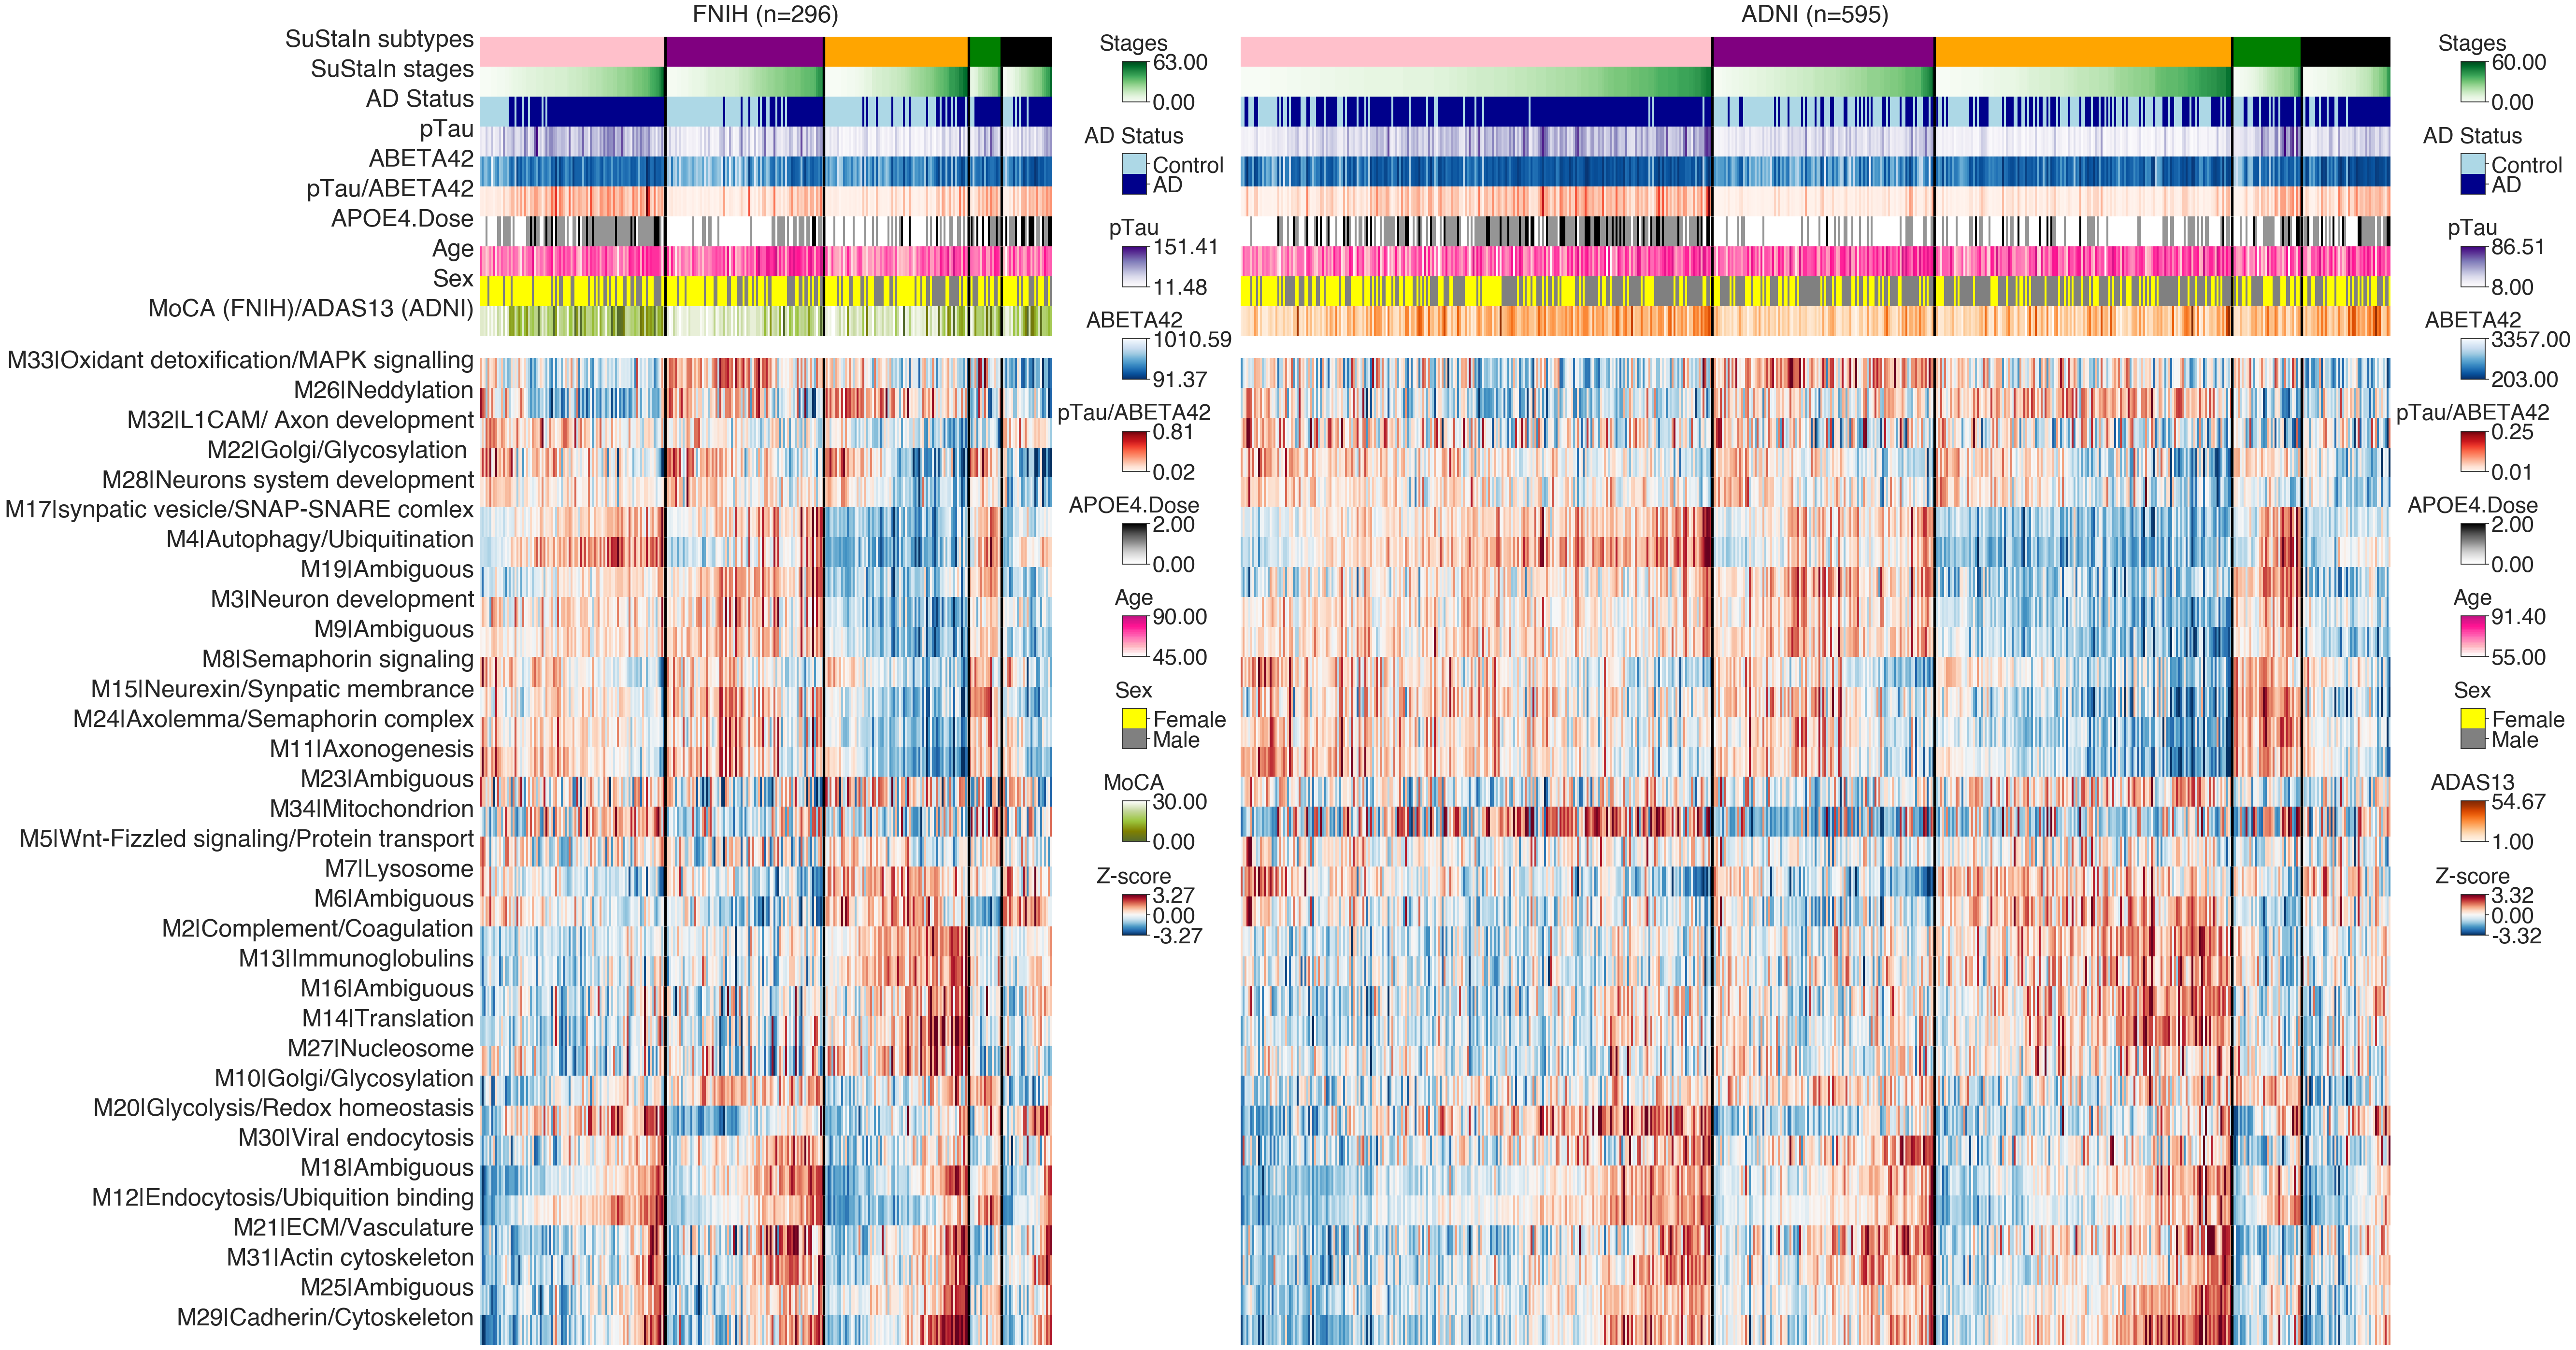

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Helvetica'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica']

sns.set_theme(style="white", font="Helvetica")

############################
# HELPER FUNCTION TO CLEAN LABELS
############################
def clean_label(label):
    """
    Remove color name from labels like 'M13|green|neurons' -> 'M13|neurons'
    """
    if '|' in label:
        parts = label.split('|')
        if len(parts) == 3:
            # Format is M#|color|description, return M#|description
            return f"{parts[0]}|{parts[2]}"
    return label

############################
# LOAD COHORT 1: FNIH (296 samples)
############################
data1_fnih = pd.read_excel(
    "FNIH296CSF-cleanDat.MEs.ModuleAssignments.Traits_forTraining_withShiva(EBD).xlsb",
    sheet_name="SUSTAIN.numericMeta-Stage+Subty",
    engine="pyxlsb"
)
data1_fnih.index = data1_fnih.iloc[:, 0]
data1_fnih = data1_fnih.iloc[:, 1:]

# Calculate pTau/ABETA42 ratio for FNIH
ptau_ab42_ratio_fnih = data1_fnih["pTau"] / data1_fnih["Abeta"]

df_meta_fnih = pd.DataFrame({
    "SuStaIn subtypes": data1_fnih["subtype_sustain_FNIH_33_eigenprotein_5_unstandardized_rbCT"],
    "SuStaIn stages": data1_fnih["stage_sustain_FNIH_33_eigenprotein_5_unstandardized_rbCT"],
    "AD Status": data1_fnih["Group"].map({"Control": 0, "AD": 1}),
    "pTau": data1_fnih["pTau"],
    "ABETA42": data1_fnih["Abeta"],
    "pTau/ABETA42": ptau_ab42_ratio_fnih,
    "APOE4.Dose": data1_fnih["APOE4.Dose"],
    "Age": data1_fnih["Age"],
    "Sex": data1_fnih["Sex"],
    "MoCA (FNIH)/ADAS13 (ADNI)": data1_fnih.get("MoCA", np.nan)  # MoCA for FNIH
})

MEs_fnih = pd.read_excel(
    "FNIH296CSF-cleanDat.MEs.ModuleAssignments.Traits_forTraining_withShiva(EBD).xlsb",
    sheet_name="MEs(34modules)",
    engine="pyxlsb"
)
MEs_fnih.index = MEs_fnih.iloc[:, 0]
MEs_fnih = MEs_fnih.iloc[:, 1:].T
MEs_fnih = MEs_fnih.drop(columns=["turquoise"])
MEs_fnih.index = df_meta_fnih.index

MEs_fnih = (MEs_fnih - MEs_fnih.mean()) / MEs_fnih.std()
color_to_ontologies = pd.read_csv("module_colors.csv")
mapping_dict = dict(zip(color_to_ontologies['Module color'], color_to_ontologies['num-col-ontology']))
MEs_fnih = MEs_fnih.rename(columns=mapping_dict)

MEs_clipped_fnih = MEs_fnih.apply(
    lambda x: x.clip(
        lower=-min(abs(x.min()), abs(x.max())),
        upper=min(abs(x.min()), abs(x.max()))), axis=0)

df_fnih = pd.concat([df_meta_fnih, MEs_clipped_fnih], axis=1)
df_fnih = df_fnih.sort_values(by=["SuStaIn subtypes", "SuStaIn stages"]).reset_index(drop=True)
protein_rows_fnih = MEs_fnih.columns.tolist()

############################
# LOAD COHORT 2: ADNI (595 samples)
############################
data1_adni = pd.read_csv("ADNI595CSF-traits.2platform.tTAMPOR_bloodEPregressed_cleanCN.csv",index_col=5)

adni_merge = pd.read_csv("ADNIMERGE_17Jul2025_filtered.csv",index_col=0)
adni_merge=adni_merge.loc[data1_adni.index]

# Map ADAS13 to ADNI data based on RID
adas13_values = adni_merge["ADAS13"]

# Calculate pTau/ABETA42 ratio for ADNI
ptau_ab42_ratio_adni = data1_adni["PTAU_bl"] / data1_adni["ABETA42_bl.1"]

df_meta_adni = pd.DataFrame({
    "SuStaIn subtypes": data1_adni["subtype_sustain_ADNI_eigenprotein_5_red_brown_cleanCT_ADNI"],
    "SuStaIn stages": data1_adni["stage_sustain_ADNI_eigenprotein_5_red_brown_cleanCT_ADNI"],
    "AD Status": data1_adni['Amyloid_status'].map({'amyloid negative': 0, 'amyloid positive': 1}),
    "pTau": data1_adni["PTAU_bl"],
    "ABETA42": data1_adni["ABETA42_bl.1"],
    "pTau/ABETA42": ptau_ab42_ratio_adni,
    "APOE4.Dose": data1_adni["APOE4"],
    "Age": data1_adni["AGE.1"],
    "Sex": data1_adni["PTGENDER.1"].map({'Female': 0, 'Male': 1}),
    "MoCA (FNIH)/ADAS13 (ADNI)": adas13_values # ADAS13 for ADNI
})

MEs_adni = pd.read_csv("SEs-CSF.34modules(template)-ADNI Synthetic Eigenproteins-4columns-imputed.csv", index_col=0)
MEs_adni = MEs_adni.drop(columns=['MEturquoise'])
MEs_adni.index = df_meta_adni.index

MEs_adni = (MEs_adni - MEs_adni.mean()) / MEs_adni.std()
MEs_adni.columns = MEs_adni.columns.str.replace("ME", "", regex=False)
MEs_adni = MEs_adni.rename(columns=mapping_dict)

MEs_clipped_adni = MEs_adni.apply(
    lambda x: x.clip(
        lower=-min(abs(x.min()), abs(x.max())),
        upper=min(abs(x.min()), abs(x.max()))), axis=0)

df_adni = pd.concat([df_meta_adni, MEs_clipped_adni], axis=1)
df_adni = df_adni.sort_values(by=["SuStaIn subtypes", "SuStaIn stages"]).reset_index(drop=True)
protein_rows_adni = MEs_adni.columns.tolist()

############################
# Define row order (same for both)
############################
annotation_rows = [
    "SuStaIn subtypes",
    "SuStaIn stages",
    "AD Status",
    "pTau",
    "ABETA42",
    "pTau/ABETA42",
    "APOE4.Dose",
    "Age",
    "Sex",
    "MoCA (FNIH)/ADAS13 (ADNI)"
]

titles = annotation_rows + protein_rows_fnih
n_rows = len(titles)

############################
# Colormaps
############################
subtype_cmap = ListedColormap(["pink", "purple", "orange", "green", "black"])
stage_cmap = sns.color_palette("Greens", as_cmap=True)
ad_cmap = ListedColormap(["lightblue", "darkblue"])
sex_cmap = ListedColormap(["yellow", "gray"])

# Custom colormaps for MoCA (white to olive-green, REVERSED) and ADAS13 (white to saddle brown)
moca_cmap = LinearSegmentedColormap.from_list('white_olive', ['#556B2F', '#808000', '#9BC53D', '#C4D79B', '#FFFFFF'], N=256)  # REVERSED
adas13_cmap = sns.color_palette("Oranges", as_cmap=True)#LinearSegmentedColormap.from_list('white_saddlebrown', ['#FFFFFF', '#F5DEB3', '#DEB887', '#D2691E', '#8B4513'], N=256)

continuous_cmaps = {
    "pTau": sns.color_palette("Purples", as_cmap=True),
    "ABETA42": sns.color_palette("Blues_r", as_cmap=True),  # REVERSED: lower = darker = worse
    "pTau/ABETA42": sns.color_palette("Reds", as_cmap=True),
    "APOE4.Dose": sns.color_palette("Greys", as_cmap=True),
    "Age": LinearSegmentedColormap.from_list('white_pink', ['#FFFFFF', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585'], N=25),
}

############################
# Calculate figure dimensions
############################
row_height = 0.7
sample_width = 0.04

n_samples_fnih = df_fnih.shape[0]
n_samples_adni = df_adni.shape[0]

# Calculate widths for each heatmap
heatmap_width_fnih = sample_width * n_samples_fnih
heatmap_width_adni = sample_width * n_samples_adni

# Fixed colorbar dimensions (in inches)
cbar_width_inches = 0.5
cbar_spacing_inches = 1.1
cbar_area_width = cbar_width_inches + cbar_spacing_inches+ 0.36 

# Gap between heatmaps (includes space for FNIH colorbars)
heatmap_gap_inches = 1.95  # Space between the two cohorts

# Total figure width (two sets of colorbars now)
fig_width = heatmap_width_fnih + cbar_area_width + heatmap_gap_inches + heatmap_width_adni + cbar_area_width+18
fig_height = row_height * 43  # Increased for additional row

# Create figure
fig = plt.figure(figsize=(fig_width, fig_height))

############################
# Define positions for both heatmaps
############################
left_margin = 0.21
gap_size = 0.015
bottom_margin = 0.05
top_margin = 0.05
n_annotation_rows = len(annotation_rows)

available_height = 1 - bottom_margin - top_margin - gap_size
row_height_normalized = available_height / n_rows

# COHORT 1 (FNIH) - LEFT SIDE
heatmap1_left = left_margin
heatmap1_width_fraction = heatmap_width_fnih / fig_width
heatmap1_right = heatmap1_left + heatmap1_width_fraction

# COHORT 2 (ADNI) - RIGHT SIDE
heatmap2_left = heatmap1_right + (cbar_area_width + heatmap_gap_inches) / fig_width
heatmap2_width_fraction = heatmap_width_adni / fig_width
heatmap2_right = heatmap2_left + heatmap2_width_fraction

############################
# PLOT HEATMAP 1: FNIH
############################
axes_fnih = []
eigenprotein_axes_fnih = []

for i, row in enumerate(titles):
    if i < n_annotation_rows:
        y_bottom = 1 - top_margin - (i + 1) * row_height_normalized
        y_top = 1 - top_margin - i * row_height_normalized
    else:
        y_bottom = 1 - top_margin - n_annotation_rows * row_height_normalized - gap_size - (i - n_annotation_rows + 1) * row_height_normalized
        y_top = 1 - top_margin - n_annotation_rows * row_height_normalized - gap_size - (i - n_annotation_rows) * row_height_normalized
    
    ax = fig.add_axes([heatmap1_left, y_bottom, heatmap1_right - heatmap1_left, y_top - y_bottom])
    axes_fnih.append(ax)

    if row == "SuStaIn subtypes":
        sns.heatmap([df_fnih[row]], cmap=subtype_cmap, ax=ax, cbar=False)
    elif row == "SuStaIn stages":
        sns.heatmap([df_fnih[row]], cmap=stage_cmap, ax=ax, cbar=False)
    elif row == "AD Status":
        sns.heatmap([df_fnih[row]], cmap=ad_cmap, ax=ax, cbar=False)
    elif row == "Sex":
        sns.heatmap([df_fnih[row]], cmap=sex_cmap, ax=ax, cbar=False)
    elif row == "MoCA (FNIH)/ADAS13 (ADNI)":
        sns.heatmap([df_fnih[row]], cmap=moca_cmap, ax=ax, cbar=False)  # MoCA colormap for FNIH
    elif row in continuous_cmaps:
        sns.heatmap([df_fnih[row]], cmap=continuous_cmaps[row], ax=ax, cbar=False)
    else:
        sns.heatmap([df_fnih[row]], cmap="RdBu_r", ax=ax, cbar=False)
        eigenprotein_axes_fnih.append(ax)
    
    # Clean the label for eigenprotein rows (remove color name)
    display_label = clean_label(row)
    ax.set_ylabel(display_label, rotation=0, ha="right", fontsize=36, labelpad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

# Vertical lines separating SuStaIn subtypes for FNIH
subtype_boundaries_fnih = np.where(
    df_fnih["SuStaIn subtypes"].values[:-1] != df_fnih["SuStaIn subtypes"].values[1:]
)[0] + 1

for ax in axes_fnih:
    for x in subtype_boundaries_fnih:
        ax.vlines(x, ymin=0, ymax=1, colors="black", linewidth=3.8)

############################
# PLOT HEATMAP 2: ADNI
############################
axes_adni = []
eigenprotein_axes_adni = []

for i, row in enumerate(titles):
    if i < n_annotation_rows:
        y_bottom = 1 - top_margin - (i + 1) * row_height_normalized
        y_top = 1 - top_margin - i * row_height_normalized
    else:
        y_bottom = 1 - top_margin - n_annotation_rows * row_height_normalized - gap_size - (i - n_annotation_rows + 1) * row_height_normalized
        y_top = 1 - top_margin - n_annotation_rows * row_height_normalized - gap_size - (i - n_annotation_rows) * row_height_normalized
    
    ax = fig.add_axes([heatmap2_left, y_bottom, heatmap2_right - heatmap2_left, y_top - y_bottom])
    axes_adni.append(ax)

    if row == "SuStaIn subtypes":
        sns.heatmap([df_adni[row]], cmap=subtype_cmap, ax=ax, cbar=False)
    elif row == "SuStaIn stages":
        sns.heatmap([df_adni[row]], cmap=stage_cmap, ax=ax, cbar=False)
    elif row == "AD Status":
        sns.heatmap([df_adni[row]], cmap=ad_cmap, ax=ax, cbar=False)
    elif row == "Sex":
        sns.heatmap([df_adni[row]], cmap=sex_cmap, ax=ax, cbar=False)
    elif row == "MoCA (FNIH)/ADAS13 (ADNI)":
        sns.heatmap([df_adni[row]], cmap=adas13_cmap, ax=ax, cbar=False)  # ADAS13 colormap for ADNI
    elif row in continuous_cmaps:
        sns.heatmap([df_adni[row]], cmap=continuous_cmaps[row], ax=ax, cbar=False)
    else:
        sns.heatmap([df_adni[row]], cmap="RdBu_r", ax=ax, cbar=False)
        eigenprotein_axes_adni.append(ax)
    
    ax.set_ylabel("")  # No labels for second heatmap
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

# Vertical lines separating SuStaIn subtypes for ADNI
subtype_boundaries_adni = np.where(
    df_adni["SuStaIn subtypes"].values[:-1] != df_adni["SuStaIn subtypes"].values[1:]
)[0] + 1

for ax in axes_adni:
    for x in subtype_boundaries_adni:
        ax.vlines(x, ymin=0, ymax=1, colors="black", linewidth=3.8)

############################
# Add colorbars for FNIH (left side)
############################
cbar_x_position_fnih = heatmap1_right + (cbar_spacing_inches / fig_width)+0.006
cbar_width = cbar_width_inches / fig_width
cbar_fontsize = 33
cbar_height_ratio = 1.35
cbar_vertical_spacing = 0.043

def add_colorbar(row_name, cmap, vmin, vmax, labels=None, is_categorical=False, cbar_offset=0, axes_ref=None, cbar_x_pos=None, cohort=None):
    """Helper function to add a colorbar for a specific row with vertical offset"""
    if row_name not in titles:
        return
    
    idx = titles.index(row_name)
    ax_pos = axes_ref[idx].get_position()
    
    cbar_height = ax_pos.height * cbar_height_ratio
    cbar_y_pos = ax_pos.y0 + (ax_pos.height - cbar_height) / 2 - cbar_offset
    
    cbar_ax = fig.add_axes([cbar_x_pos, cbar_y_pos, cbar_width, cbar_height])
    
    if is_categorical:
        n_categories = len(labels)
        cbar_ax.imshow([[i] for i in range(n_categories)], cmap=cmap, aspect='auto')
        cbar_ax.set_yticks(range(n_categories))
        cbar_ax.set_yticklabels(labels, fontsize=cbar_fontsize)
        cbar_ax.yaxis.tick_right()
        cbar_ax.set_xticks([])
    else:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')

        # CRITICAL FIX FOR PDF EXPORT
        cbar.solids.set_edgecolor("face")
        cbar.solids.set_linewidth(0)
        cbar.solids.set_rasterized(True)

        cbar.set_ticks([vmin, vmax])
        cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"], fontsize=cbar_fontsize)
    
    title_map = {
        "SuStaIn stages": "Stages",
        "AD Status": "AD Status",
        "pTau": "pTau",
        "ABETA42": "ABETA42",
        "pTau/ABETA42": "pTau/ABETA42",
        "APOE4.Dose": "APOE4.Dose",
        "Age": "Age",
        "Sex": "Sex",
        "MoCA (FNIH)/ADAS13 (ADNI)": "MoCA" if cohort == "FNIH" else "ADAS13"
    }
    cbar_ax.set_title(title_map.get(row_name, row_name), fontsize=cbar_fontsize, pad=17)

# FNIH colorbars
add_colorbar("SuStaIn stages", stage_cmap, df_fnih["SuStaIn stages"].min(), df_fnih["SuStaIn stages"].max(), 
             cbar_offset=0, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")
add_colorbar("AD Status", ad_cmap, 0, 1, labels=["Control", "AD"], is_categorical=True, 
             cbar_offset=cbar_vertical_spacing, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")
add_colorbar("pTau", continuous_cmaps["pTau"], df_fnih["pTau"].min(), df_fnih["pTau"].max(), 
             cbar_offset=cbar_vertical_spacing*2, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")
add_colorbar("ABETA42", continuous_cmaps["ABETA42"], df_fnih["ABETA42"].min(), df_fnih["ABETA42"].max(), 
             cbar_offset=cbar_vertical_spacing*3, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")
add_colorbar("pTau/ABETA42", continuous_cmaps["pTau/ABETA42"], df_fnih["pTau/ABETA42"].min(), df_fnih["pTau/ABETA42"].max(), 
             cbar_offset=cbar_vertical_spacing*4, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")
add_colorbar("APOE4.Dose", continuous_cmaps["APOE4.Dose"], df_fnih["APOE4.Dose"].min(), df_fnih["APOE4.Dose"].max(), 
             cbar_offset=cbar_vertical_spacing*5, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")
add_colorbar("Age", continuous_cmaps["Age"], df_fnih["Age"].min(), df_fnih["Age"].max(), 
             cbar_offset=cbar_vertical_spacing*6, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")
add_colorbar("Sex", sex_cmap, 0, 1, labels=["Female", "Male"], is_categorical=True, 
             cbar_offset=cbar_vertical_spacing*7, axes_ref=axes_fnih, cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")

# Add MoCA colorbar for FNIH
if not df_fnih["MoCA (FNIH)/ADAS13 (ADNI)"].isna().all():
    add_colorbar("MoCA (FNIH)/ADAS13 (ADNI)", moca_cmap, 
                 df_fnih["MoCA (FNIH)/ADAS13 (ADNI)"].min(), 
                 df_fnih["MoCA (FNIH)/ADAS13 (ADNI)"].max(), 
                 cbar_offset=cbar_vertical_spacing*8, axes_ref=axes_fnih, 
                 cbar_x_pos=cbar_x_position_fnih, cohort="FNIH")

# FNIH eigenprotein colorbar - RIGHT AFTER MoCA with proper spacing
if eigenprotein_axes_fnih:
    # Get the position of MoCA colorbar and place Z-score right below it
    moca_idx = titles.index("MoCA (FNIH)/ADAS13 (ADNI)")
    ax_pos = axes_fnih[moca_idx].get_position()
    
    # Calculate position: same approach as other colorbars but with offset of 9
    cbar_height = ax_pos.height * cbar_height_ratio
    cbar_y_pos = ax_pos.y0 + (ax_pos.height - cbar_height) / 2 - cbar_vertical_spacing*9.5
    
    cbar_ax = fig.add_axes([cbar_x_position_fnih, cbar_y_pos, cbar_width, cbar_height])
    
    all_eigen_fnih = df_fnih[protein_rows_fnih].values.flatten()
    vmin_fnih = all_eigen_fnih.min()
    vmax_fnih = all_eigen_fnih.max()
    
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=vmin_fnih, vmax=vmax_fnih))
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
    
    # CRITICAL FIX FOR PDF EXPORT
    cbar.solids.set_edgecolor("face")
    cbar.solids.set_linewidth(0)
    cbar.solids.set_rasterized(True)
    
    cbar.set_ticks([vmin_fnih, 0, vmax_fnih])
    cbar.set_ticklabels([f"{vmin_fnih:.2f}", "0.00", f"{vmax_fnih:.2f}"], fontsize=cbar_fontsize)
    cbar_ax.set_title("Z-score", fontsize=cbar_fontsize, pad=17)

############################
# Add colorbars for ADNI (right side)
############################
cbar_x_position_adni = heatmap2_right + (cbar_spacing_inches / fig_width)+0.006

# ADNI colorbars
add_colorbar("SuStaIn stages", stage_cmap, df_adni["SuStaIn stages"].min(), df_adni["SuStaIn stages"].max(), 
             cbar_offset=0, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")
add_colorbar("AD Status", ad_cmap, 0, 1, labels=["Control", "AD"], is_categorical=True, 
             cbar_offset=cbar_vertical_spacing, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")
add_colorbar("pTau", continuous_cmaps["pTau"], df_adni["pTau"].min(), df_adni["pTau"].max(), 
             cbar_offset=cbar_vertical_spacing*2, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")
add_colorbar("ABETA42", continuous_cmaps["ABETA42"], df_adni["ABETA42"].min(), df_adni["ABETA42"].max(), 
             cbar_offset=cbar_vertical_spacing*3, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")
add_colorbar("pTau/ABETA42", continuous_cmaps["pTau/ABETA42"], df_adni["pTau/ABETA42"].min(), df_adni["pTau/ABETA42"].max(), 
             cbar_offset=cbar_vertical_spacing*4, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")
add_colorbar("APOE4.Dose", continuous_cmaps["APOE4.Dose"], df_adni["APOE4.Dose"].min(), df_adni["APOE4.Dose"].max(), 
             cbar_offset=cbar_vertical_spacing*5, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")
add_colorbar("Age", continuous_cmaps["Age"], df_adni["Age"].min(), df_adni["Age"].max(), 
             cbar_offset=cbar_vertical_spacing*6, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")
add_colorbar("Sex", sex_cmap, 0, 1, labels=["Female", "Male"], is_categorical=True, 
             cbar_offset=cbar_vertical_spacing*7, axes_ref=axes_adni, cbar_x_pos=cbar_x_position_adni, cohort="ADNI")

# Add ADAS13 colorbar for ADNI
if not df_adni["MoCA (FNIH)/ADAS13 (ADNI)"].isna().all():
    add_colorbar("MoCA (FNIH)/ADAS13 (ADNI)", adas13_cmap, 
                 df_adni["MoCA (FNIH)/ADAS13 (ADNI)"].min(), 
                 df_adni["MoCA (FNIH)/ADAS13 (ADNI)"].max(), 
                 cbar_offset=cbar_vertical_spacing*8, axes_ref=axes_adni, 
                 cbar_x_pos=cbar_x_position_adni, cohort="ADNI")

# ADNI eigenprotein colorbar - RIGHT AFTER ADAS13 with proper spacing
if eigenprotein_axes_adni:
    # Get the position of ADAS13 colorbar and place Z-score right below it
    adas_idx = titles.index("MoCA (FNIH)/ADAS13 (ADNI)")
    ax_pos = axes_adni[adas_idx].get_position()
    
    # Calculate position: same approach as other colorbars but with offset of 9
    cbar_height = ax_pos.height * cbar_height_ratio
    cbar_y_pos = ax_pos.y0 + (ax_pos.height - cbar_height) / 2 - cbar_vertical_spacing*9.5
    
    cbar_ax = fig.add_axes([cbar_x_position_adni, cbar_y_pos, cbar_width, cbar_height])
    
    all_eigen_adni = df_adni[protein_rows_adni].values.flatten()
    vmin_adni = all_eigen_adni.min()
    vmax_adni = all_eigen_adni.max()
    
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=vmin_adni, vmax=vmax_adni))
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
    
    # CRITICAL FIX FOR PDF EXPORT
    cbar.solids.set_edgecolor("face")
    cbar.solids.set_linewidth(0)
    cbar.solids.set_rasterized(True)
    
    cbar.set_ticks([vmin_adni, 0, vmax_adni])
    cbar.set_ticklabels([f"{vmin_adni:.2f}", "0.00", f"{vmax_adni:.2f}"], fontsize=cbar_fontsize)
    cbar_ax.set_title("Z-score", fontsize=cbar_fontsize, pad=17)

############################
# Add cohort labels
############################
fig.text(heatmap1_left + (heatmap1_right - heatmap1_left)/2, 0.96, 
         f'FNIH (n={n_samples_fnih})', ha='center', fontsize=36, fontweight='bold')
fig.text(heatmap2_left + (heatmap2_right - heatmap2_left)/2, 0.96, 
         f'ADNI (n={n_samples_adni})', ha='center', fontsize=36, fontweight='bold')
 # Ensure space on right
fig.subplots_adjust(
    left=0.03,
    right=0.995,
    top=0.97,
    bottom=0.03
)

plt.savefig("FNIH_ADNI_SuStaIn_Heatmap.pdf", dpi=600)

plt.show()